In [9]:

using Pkg
Pkg.activate(joinpath(@__DIR__, "../.."))

using GeneralizedPerturbedEquilibrium
const FT = GeneralizedPerturbedEquilibrium.ForcingTerms
const read_coil_dat = FT.read_coil_dat
const compute_biot_savart_boundary! = FT.compute_biot_savart_boundary!

function export_hall_csv_notebook(;
    coil_file::String,
    out_csv::String = "hall_output.csv",
    current_A::Float64 = 100.0,
    R_inner_m::Float64 = 0.10,
    R_outer_m::Float64 = 0.15,
    nphi_inner::Int = 24,
    nz_inner::Int = 22,
    nphi_outer::Int = 20,
    nz_outer::Int = 10,
    zspan_inner::Float64 = 0.60,
    zspan_outer::Float64 = 0.40,
    z0::Float64 = 0.0
)

    cs = read_coil_dat(coil_file)
    cs.currents .= current_A
    coils = [cs]

    # --- Hall grid (cylindrical) ---
    φi = collect(range(0, 2π, length=nphi_inner+1)[1:end-1])
    φo = collect(range(0, 2π, length=nphi_outer+1)[1:end-1])

    Zi = collect(range(z0 - zspan_inner, z0 + zspan_inner; length=nz_inner))
    Zo = collect(range(z0 - zspan_outer, z0 + zspan_outer; length=nz_outer))

    N = nphi_inner*nz_inner + nphi_outer*nz_outer

    R = zeros(N)
    φ = zeros(N)
    Z = zeros(N)
    shell = zeros(Int, N)

    k = 1
    for iz in eachindex(Zi), ip in eachindex(φi)
        R[k] = R_inner_m
        φ[k] = φi[ip]
        Z[k] = Zi[iz]
        shell[k] = 1
        k += 1
    end

    for iz in eachindex(Zo), ip in eachindex(φo)
        R[k] = R_outer_m
        φ[k] = φo[ip]
        Z[k] = Zo[iz]
        shell[k] = 2
        k += 1
    end

    # --- Field evaluation ---
    BR = zeros(N)
    BP = zeros(N)
    BZ = zeros(N)

    compute_biot_savart_boundary!(BR, BP, BZ, R, φ, Z, coils)
    Bmag = sqrt.(BR.^2 .+ BP.^2 .+ BZ.^2)

    # --- Export CSV ---
    open(out_csv, "w") do io
        println(io, "x,y,z,R,phi,shell,B_R,B_phi,B_Z,B_mag")
        for i in 1:N
            x = R[i] * cos(φ[i])
            y = R[i] * sin(φ[i])
            println(io, "$(x),$(y),$(Z[i]),$(R[i]),$(φ[i]),$(shell[i]),$(BR[i]),$(BP[i]),$(BZ[i]),$(Bmag[i])")
        end
    end

    out_csv
end

  Activating project at `~/Documents/GitHub/JULIA_GPEC`


export_hall_csv_notebook (generic function with 1 method)

In [10]:
include("tilt_shift.jl")

phys_file  = "sparc_pf1u.dat"
field_file = "out_3mm.dat"

# ---------------------------------------------------------
# 1) generate shifted coil
# ---------------------------------------------------------
transform_coil(
    phys_file,
    field_file;
    shift_x    = 0.000,
    shift_y    = 0.000,
    shift_z    = 0.000,
    tilt_x_deg = 0.1,
    tilt_y_deg = 0.0,
    tilt_z_deg = 0.0,
)

# ---------------------------------------------------------
# 2) Hall data from shifted coil
# ---------------------------------------------------------
export_hall_csv_notebook(
    coil_file = field_file,
    out_csv   = "hall_probe_example.csv",
    current_A = 100.0
)

# ---------------------------------------------------------
# 3) full pipeline (physical + field)
# ---------------------------------------------------------
include("coil_centering_full.jl")

results = run_coil_axis_comparison(
    run_name             = "out_3mm",
    script_dir           = "./",
    coil_current_a       = 100.0,
    physical_coil_file   = phys_file,

    field_hall_mode      = :internal,
    field_hall_input_csv = "hall_probe_example.csv",

    physical_hall_mode   = :internal,
    display_axis_plot    = false
)

# ---------------------------------------------------------
# 4) extract comparable objects
# ---------------------------------------------------------
phys = results.physical_corrected
fld  = results.field_corrected

# ---------------------------------------------------------
# 5) one-line difference (FIELD - PHYSICAL)
# ---------------------------------------------------------
dx  = (fld.x0 - phys.x0) * 1e3
dy  = (fld.y0 - phys.y0) * 1e3
dz  = (fld.z0 - phys.z0) * 1e3
dtx = fld.tilt_x - phys.tilt_x
dty = fld.tilt_y - phys.tilt_y

@printf(
    "ΔFIELD-PHYSICAL: dx=%+.4f mm  dy=%+.4f mm  dz=%+.4f mm  dtx=%+.6f°  dty=%+.6f°\n",
    dx, dy, dz, dtx, dty
)


Loaded PHYSICAL coil:


  Activating project at `~/Documents/GitHub/JULIA_GPEC`


  file = sparc_pf1u.dat
  ncoil=1, s=1, nsec=30600, I=100.0 A

Loaded FIELD coil:
  file = ./out_3mm.dat
  ncoil=1, s=1, nsec=30600, I=100.0 A

Physical geom:
  center = (-2.423, 1.082, 2307.411) mm
  tilt_x = 0.047918 deg, tilt_y = 0.102029 deg
  fit radius = 928.829 mm
  R range = [705.437, 1256.983] mm
  Z range = [2185.500, 3033.600] mm

Field geom:
  center = (-2.423, 1.082, 2307.411) mm
  tilt_x = 0.147910 deg, tilt_y = 0.102008 deg
  fit radius = 928.829 mm
  R range = [705.240, 1256.832] mm
  Z range = [2183.700, 3035.200] mm

Computing synthetic Hall data from PHYSICAL coil:
  probes = 728
  R1 = 282.175 mm, Z1=[1707.411, 2907.411] mm
  R2 = 628.491 mm, Z2=[1907.411, 2707.411] mm

Exported Hall CSV: ./hall_probe_out_3mm_PHYSICAL.csv

B_R zero-crossing sinusoid, PHYSICAL, shell 1:
  valid = 24/24, Z0 = 2307.128520 mm, tilt_x = -0.011056 deg, tilt_y = -0.033941 deg

B_R zero-crossing sinusoid, PHYSICAL, shell 2:
  valid = 20/20, Z0 = 2307.664398 mm, tilt_x = 0.058041 deg, tilt_y

In [11]:
using Printf
# ---------------------------------------------------------
# 0) Setup suppression
# ---------------------------------------------------------
# Open a null device to swallow the output
out = devnull 

include("tilt_shift.jl")

phys_file  = "sparc_pf1u.dat"
field_file = "out_3mm.dat"

# Wrap all noisy functions in this block
redirect_stdout(out) do
    # ---------------------------------------------------------
    # 1) generate shifted coil
    # ---------------------------------------------------------
    transform_coil(
        phys_file,
        field_file;
        shift_x    = 0.000,
        shift_y    = 0.000,
        shift_z    = 0.000,
        tilt_x_deg = 0.1,
        tilt_y_deg = 0.0,
        tilt_z_deg = 0.0,
    )

    # ---------------------------------------------------------
    # 2) Hall data from shifted coil
    # ---------------------------------------------------------
    export_hall_csv_notebook(
        coil_file = field_file,
        out_csv   = "hall_probe_example.csv",
        current_A = 100.0
    )

    # ---------------------------------------------------------
    # 3) full pipeline (physical + field)
    # ---------------------------------------------------------
    include("coil_centering_full.jl")

    global results = run_coil_axis_comparison(
        run_name             = "out_3mm",
        script_dir           = "./",
        coil_current_a       = 100.0,
        physical_coil_file   = phys_file,
        field_hall_mode      = :internal,
        field_hall_input_csv = "hall_probe_example.csv",
        physical_hall_mode   = :internal,
        display_axis_plot    = false
    )
end # End of suppression

# ---------------------------------------------------------
# 4) extract comparable objects
# ---------------------------------------------------------
phys = results.physical_corrected
fld  = results.field_corrected

# ---------------------------------------------------------
# 5) one-line difference (FIELD - PHYSICAL)
# ---------------------------------------------------------
dx  = (fld.x0 - phys.x0) * 1e3
dy  = (fld.y0 - phys.y0) * 1e3
dz  = (fld.z0 - phys.z0) * 1e3
dtx = fld.tilt_x - phys.tilt_x
dty = fld.tilt_y - phys.tilt_y

# This will print normally because it is outside the redirect_stdout block
@printf(
    "ΔFIELD-PHYSICAL: dx=%+.4f mm  dy=%+.4f mm  dz=%+.4f mm  dtx=%+.6f°  dty=%+.6f°\n",
    dx, dy, dz, dtx, dty
)

  Activating project at `~/Documents/GitHub/JULIA_GPEC`


ΔFIELD-PHYSICAL: dx=-0.0001 mm  dy=-0.0000 mm  dz=+0.0004 mm  dtx=+0.099995°  dty=-0.000024°


In [12]:
using Printf

function run_scan(; shift_x=0.003, shift_y=0.005, shift_z=0.007, tilt_x_deg=0.0, tilt_y_deg=0.0, current_A = 100.0)
    # ---------------------------------------------------------
    # 0) Setup suppression
    # ---------------------------------------------------------
    # Open a null device to swallow the output
    out = devnull 

    include("tilt_shift.jl")

    phys_file  = "sparc_pf1u.dat"
    field_file = "coil_out.dat"

    # Wrap all noisy functions in this block
    redirect_stdout(out) do
        # ---------------------------------------------------------
        # 1) generate shifted coil
        # ---------------------------------------------------------
        transform_coil(
            phys_file,
            field_file;
            shift_x    = shift_x,
            shift_y    = shift_y,
            shift_z    = shift_z,
            tilt_x_deg = tilt_x_deg,
            tilt_y_deg = tilt_y_deg,
            tilt_z_deg = 0.0,
        )

        # ---------------------------------------------------------
        # 2) Hall data from shifted coil
        # ---------------------------------------------------------
        export_hall_csv_notebook(
            coil_file = field_file,
            out_csv   = "hall_probe_out.csv",
            current_A = current_A
        )

        # ---------------------------------------------------------
        # 3) full pipeline (physical + field)
        # ---------------------------------------------------------
        include("coil_centering_full.jl")

        global results = run_coil_axis_comparison(
            run_name             = "coil_out",
            script_dir           = "./",
            coil_current_a       = current_A,
            physical_coil_file   = phys_file,
            field_hall_mode      = :internal,
            field_hall_input_csv = "hall_probe_out.csv",
            physical_hall_mode   = :internal,
            display_axis_plot    = false
        )
    end # End of suppression

    # ---------------------------------------------------------
    # 4) extract comparable objects
    # ---------------------------------------------------------
    phys = results.physical_corrected
    fld  = results.field_corrected

    # ---------------------------------------------------------
    # 5) one-line difference (FIELD - PHYSICAL)
    # ---------------------------------------------------------
    dx  = (fld.x0 - phys.x0) * 1e3
    dy  = (fld.y0 - phys.y0) * 1e3
    dz  = (fld.z0 - phys.z0) * 1e3
    dtx = fld.tilt_x - phys.tilt_x
    dty = fld.tilt_y - phys.tilt_y

    # This will print normally because it is outside the redirect_stdout block
    @printf(
        "ΔFIELD-PHYSICAL: dx=%+.4f mm  dy=%+.4f mm  dz=%+.4f mm  dtx=%+.6f°  dty=%+.6f°\n",
        dx, dy, dz, dtx, dty
    )
end

run_scan (generic function with 1 method)

In [13]:
# run scan with x shifts of 1, 3, 5, 10 mnm:
for shift in [0.01, 0.03, 0.05, 0.10, 1, 10, 50]
    run_scan(shift_x=.001, shift_y=0.005, shift_z=0.007, tilt_x_deg=shift, tilt_y_deg=0.0, current_A = 100.0)
end

  Activating project at `~/Documents/GitHub/JULIA_GPEC`


ΔFIELD-PHYSICAL: dx=+1.0000 mm  dy=+4.9998 mm  dz=+7.0000 mm  dtx=+0.009623°  dty=+0.000001°


  Activating project at `~/Documents/GitHub/JULIA_GPEC`


ΔFIELD-PHYSICAL: dx=+1.0000 mm  dy=+5.0002 mm  dz=+7.0008 mm  dtx=+0.029849°  dty=+0.000020°


  Activating project at `~/Documents/GitHub/JULIA_GPEC`


...

ΔFIELD-PHYSICAL: dx=+0.9999 mm  dy=+5.0006 mm  dz=+7.0042 mm  dtx=+1.000018°  dty=+0.000017°


  Activating project at `~/Documents/GitHub/JULIA_GPEC`


ΔFIELD-PHYSICAL: dx=+1.0159 mm  dy=+4.8223 mm  dz=+7.1358 mm  dtx=+9.979791°  dty=+0.001646°


  Activating project at `~/Documents/GitHub/JULIA_GPEC`


ΔFIELD-PHYSICAL: dx=+1.0047 mm  dy=+4.6185 mm  dz=+7.3110 mm  dtx=+50.117132°  dty=+0.051223°


In [14]:
include("coil_centering_full.jl")

results = run_coil_axis_comparison(
    run_name       = "sparc_pf1u_357_test",
    script_dir     = "./",
    coil_current_a = 100.0,
    field_hall_mode = :internal,
    display_axis_plot = false,   # suppress readline() in notebook
    hall_r_inner_frac       = 0.40,
    hall_r_outer_frac       = 0.70,
    
)
println("Results: ", results.field_corrected)
# print results analysis x0 from sinavg
println("x0 from sinavg: ", results.field_analysis.sinavg.x0)


Loaded PHYSICAL coil:


  Activating project at `~/Documents/GitHub/JULIA_GPEC`


  file = ./sparc_pf1u.dat
  ncoil=1, s=1, nsec=30600, I=100.0 A

Loaded FIELD coil:
  file = ./sparc_pf1u_357_test.dat
  ncoil=1, s=1, nsec=30600, I=100.0 A

Physical geom:
  center = (-2.423, 1.082, 2307.411) mm
  tilt_x = 0.047918 deg, tilt_y = 0.102029 deg
  fit radius = 928.829 mm
  R range = [705.437, 1256.983] mm
  Z range = [2185.500, 3033.600] mm

Field geom:
  center = (0.712, 6.240, 2314.240) mm
  tilt_x = 0.340554 deg, tilt_y = 0.606225 deg
  fit radius = 928.829 mm
  R range = [709.239, 1258.091] mm
  Z range = [2181.700, 3052.600] mm

Computing synthetic Hall data from PHYSICAL coil:
  probes = 728
  R1 = 282.175 mm, Z1=[1707.411, 2907.411] mm
  R2 = 879.888 mm, Z2=[1907.411, 2707.411] mm

Exported Hall CSV: ./hall_probe_sparc_pf1u_357_test_PHYSICAL.csv

B_R zero-crossing sinusoid, PHYSICAL, shell 1:
  valid = 24/24, Z0 = 2307.128520 mm, tilt_x = -0.011056 deg, tilt_y = -0.033941 deg

B_R zero-crossing sinusoid, PHYSICAL, shell 2:
  valid = 20/20, Z0 = 2307.926682 mm, tilt

In [15]:
function run_scan(; kwargs...)
    # -----------------------------
    # Defaults
    # -----------------------------
    defaults = (
        shift_x = 0.0,
        shift_y = 0.0,
        shift_z = 0.0,

        tilt_x_deg = 0.0,
        tilt_y_deg = 0.0,
        tilt_z_deg = 0.0,

        current_A = 100.0,

        n_phi_inner = 24,
        n_z_inner   = 22,

        hall_n_phi_outer = nothing,
        hall_n_z_outer   = nothing,

        hall_r_inner_frac       = 0.40,
        hall_r_outer_frac       = 0.50,
        hall_z_halfspan_inner_m = 0.60,
        hall_z_halfspan_outer_m = 0.40,

        field_hall_mode      = :internal,
        physical_hall_mode   = :internal,

        tilt_calibration_radius_m = NaN,
        add_noise_frac            = 0.0,
        br_zero_noise_frac        = 0.0,
        br_min_frac_for_fourier_xy= 0.10,
        bphi_sign                 = 1.0,
        xy_min_step0_m            = 0.050,
        xy_min_tol_m              = 1e-8,
        bias_correction_n_iter    = 4,
        bias_correction_damping   = 0.6,

        enable_axis_plot  = false,
        display_axis_plot = false,

        phys_file  = "sparc_pf1u.dat",
        field_file = "coil_out.dat",
        hall_csv   = "A_Hall_Test.csv",
    )

    # Merge user kwargs into defaults
    p = merge(defaults, kwargs)

    # Auto outer-grid scaling if not explicitly provided
    hall_n_phi_outer = isnothing(p.hall_n_phi_outer) ?
        Int(round(p.n_phi_inner * 0.8)) :
        p.hall_n_phi_outer

    hall_n_z_outer = isnothing(p.hall_n_z_outer) ?
        Int(round(p.n_z_inner * 0.5)) :
        p.hall_n_z_outer

    local_results = nothing

    redirect_stdout(devnull) do

        # ---------------------------------
        # 1) Generate coil geometry
        # ---------------------------------
        transform_coil(
            p.phys_file,
            p.field_file;

            shift_x   = p.shift_x,
            shift_y   = p.shift_y,
            shift_z   = p.shift_z,

            tilt_x_deg = p.tilt_x_deg,
            tilt_y_deg = p.tilt_y_deg,
            tilt_z_deg = p.tilt_z_deg,
        )

        # ---------------------------------
        # 2) Export Hall Data
        # ---------------------------------
        export_hall_csv_notebook(
            coil_file = p.field_file,
            out_csv   = p.hall_csv,
            current_A = p.current_A
        )

        # ---------------------------------
        # 3) Full pipeline
        # ---------------------------------
        local_results = run_coil_axis_comparison(

            run_name           = "res_scan",
            script_dir         = @__DIR__,

            coil_current_a     = p.current_A,

            physical_coil_file = joinpath(@__DIR__, p.phys_file),
            field_coil_file    = joinpath(@__DIR__, p.field_file),

            hall_n_phi_inner = p.n_phi_inner,
            hall_n_z_inner   = p.n_z_inner,

            hall_n_phi_outer = hall_n_phi_outer,
            hall_n_z_outer   = hall_n_z_outer,

            hall_r_inner_frac       = p.hall_r_inner_frac,
            hall_r_outer_frac       = p.hall_r_outer_frac,

            hall_z_halfspan_inner_m = p.hall_z_halfspan_inner_m,
            hall_z_halfspan_outer_m = p.hall_z_halfspan_outer_m,

            field_hall_mode         = p.field_hall_mode,
            field_hall_input_csv    = joinpath(@__DIR__, p.hall_csv),
            physical_hall_mode      = p.physical_hall_mode,

            tilt_calibration_radius_m = p.tilt_calibration_radius_m,
            add_noise_frac            = p.add_noise_frac,
            br_zero_noise_frac        = p.br_zero_noise_frac,
            br_min_frac_for_fourier_xy= p.br_min_frac_for_fourier_xy,
            bphi_sign                 = p.bphi_sign,
            xy_min_step0_m            = p.xy_min_step0_m,
            xy_min_tol_m              = p.xy_min_tol_m,
            bias_correction_n_iter    = p.bias_correction_n_iter,
            bias_correction_damping   = p.bias_correction_damping,

            enable_axis_plot          = p.enable_axis_plot,
            display_axis_plot         = p.display_axis_plot,
        )
    end

    phys = local_results.physical_corrected
    fld  = local_results.field_corrected

    dx = (fld.x0 - phys.x0) * 1e3
    dy = (fld.y0 - phys.y0) * 1e3

    dr = sqrt(dx^2 + dy^2)

    return dr, phys, fld, local_results
end

run_scan (generic function with 1 method)

In [149]:
# Test grid sizes from 8x8 up to 48x48
println("x diff (mm) | y diff (mm) | z diff (mm) | tilt_x diff (deg) | tilt_y diff (deg)")
shifts = [.00001,.0001, .001,.01, .1]
a = []
for shift in shifts
    #store sx, sy, sz
    dr, phys, fld, lr = run_scan(
        shift_x=shift, 
        shift_y=0,#shift*2,
        shift_z=0,#shift*3, 
        tilt_x_deg=0,#shift*10000, 
    )
    # print diffs between field and physical for each run
    println("-------------------------------------------------------------")

    dx = (fld.x0 - phys.x0) * 1e3
    dy = (fld.y0 - phys.y0) * 1e3
    dz = (fld.z0 - phys.z0) * 1e3
    dtx = fld.tilt_x - phys.tilt_x
    dty = fld.tilt_y - phys.tilt_y
    @printf("%10.4f | %10.4f | %10.4f | %18.6f | %18.6f\n", dx, dy, dz, dtx, dty) 
    a = lr
end

x diff (mm) | y diff (mm) | z diff (mm) | tilt_x diff (deg) | tilt_y diff (deg)
-------------------------------------------------------------
    0.0096 |    -0.0000 |    -0.0000 |          -0.000000 |           0.000000
-------------------------------------------------------------
    0.1000 |     0.0000 |     0.0000 |           0.000000 |          -0.000000
-------------------------------------------------------------
    1.0000 |     0.0000 |     0.0000 |          -0.000000 |          -0.000000
-------------------------------------------------------------
   10.0000 |     0.0000 |     0.0001 |          -0.000001 |          -0.000003
-------------------------------------------------------------
  100.0001 |    -0.0000 |     0.0017 |          -0.000025 |          -0.000362


In [160]:
# print keys in local_results for debugging
println("Keys in local_results: ", keys(a))
# print x0 for each result in local_results (:phys_geom, :field_geom, :physical_analysis, :field_analysis, :physical_corrected, :field_corrected, :fig)
println("Phys_geom",  a.phys_geom.x0)
println("Field_geom", a.field_geom.x0)
#println("Physical Analysis", a.physical_analysis.x0)
#println("Field Analysis", a.field_analysis.x0)
println("Physical Corrected", a.physical_corrected.x0)
println("Field Corrected", a.field_corrected.x0)
# print keys in field analysis
println("Keys in field_analysis: ", keys(a.field_analysis))
#print both sin and fxy 1 and 2 and Average
println("Field Analysis - sin1: ", a.field_analysis.sin1)
println("Field Analysis - sin2: ", a.field_analysis.sin2)
println("Field Analysis - fxy1: ", a.field_analysis.fou1)
println("Field Analysis - fxy2: ", a.field_analysis.fou2)
println("Field Analysis - avg: ", a.field_analysis.sinavg)
println("Field Analysis - favg: ", a.field_analysis.fouavg)

Keys in local_results: (:phys_geom, :field_geom, :physical_analysis, :field_analysis, :physical_corrected, :field_corrected, :fig)
Phys_geom-0.002422875782886974
Field_geom0.0975774071440384
Physical Corrected-0.002422243973652355
Field Corrected0.09757786013933868
Keys in field_analysis: (:label, :h, :zt1, :zt2, :sin1, :sin2, :sinavg, :fxy1, :fxy2, :fou1, :fou2, :fouavg)
Field Analysis - sin1: (shell = 1, R = 0.27606112902761226, x0 = 0.09869427897783967, y0 = -0.0025498202772226437, z0 = 2.3071822006523655, tilt_x = -0.01396634611814834, tilt_y = -0.0319641196925431, tilt_mag = 0.03488214115577108, objective = 1.787730371148313e-7)
Field Analysis - sin2: (shell = 2, R = 0.6118426886259245, x0 = 0.09839835383745879, y0 = -0.0029177239866342644, z0 = 2.3076998085838505, tilt_x = 0.07025791105417906, tilt_y = -0.011951753505930302, tilt_mag = 0.07126723284626289, objective = 2.127599720158857e-6)
Field Analysis - fxy1: (shell = 1, R = 0.27606112902761226, x0 = 0.0974880911397654, y0 = -

In [181]:
# Test grid sizes from 8x8 up to 48x48
resolutions = [.00001,.0001, .001, .01, .1]
for shift in shifts
    run_scan(
        shift_x=shift, 
        shift_y=0.000,
        shift_z=0.00, 
        tilt_x_deg=0.0, 
        tilt_y_deg=0.0,
        add_noise_frac = 0.0,
    )
end

┌ Warning: Found `resolution` in the theme when creating a `Scene`. The `resolution` keyword for `Scene`s and `Figure`s has been deprecated. Use `Figure(; size = ...` or `Scene(; size = ...)` instead, which better reflects that this is a unitless size and not a pixel resolution. The key could also come from `set_theme!` calls or related theming functions.
└ @ Makie /Users/bursche/.julia/packages/Makie/kJl0u/src/scenes.jl:264


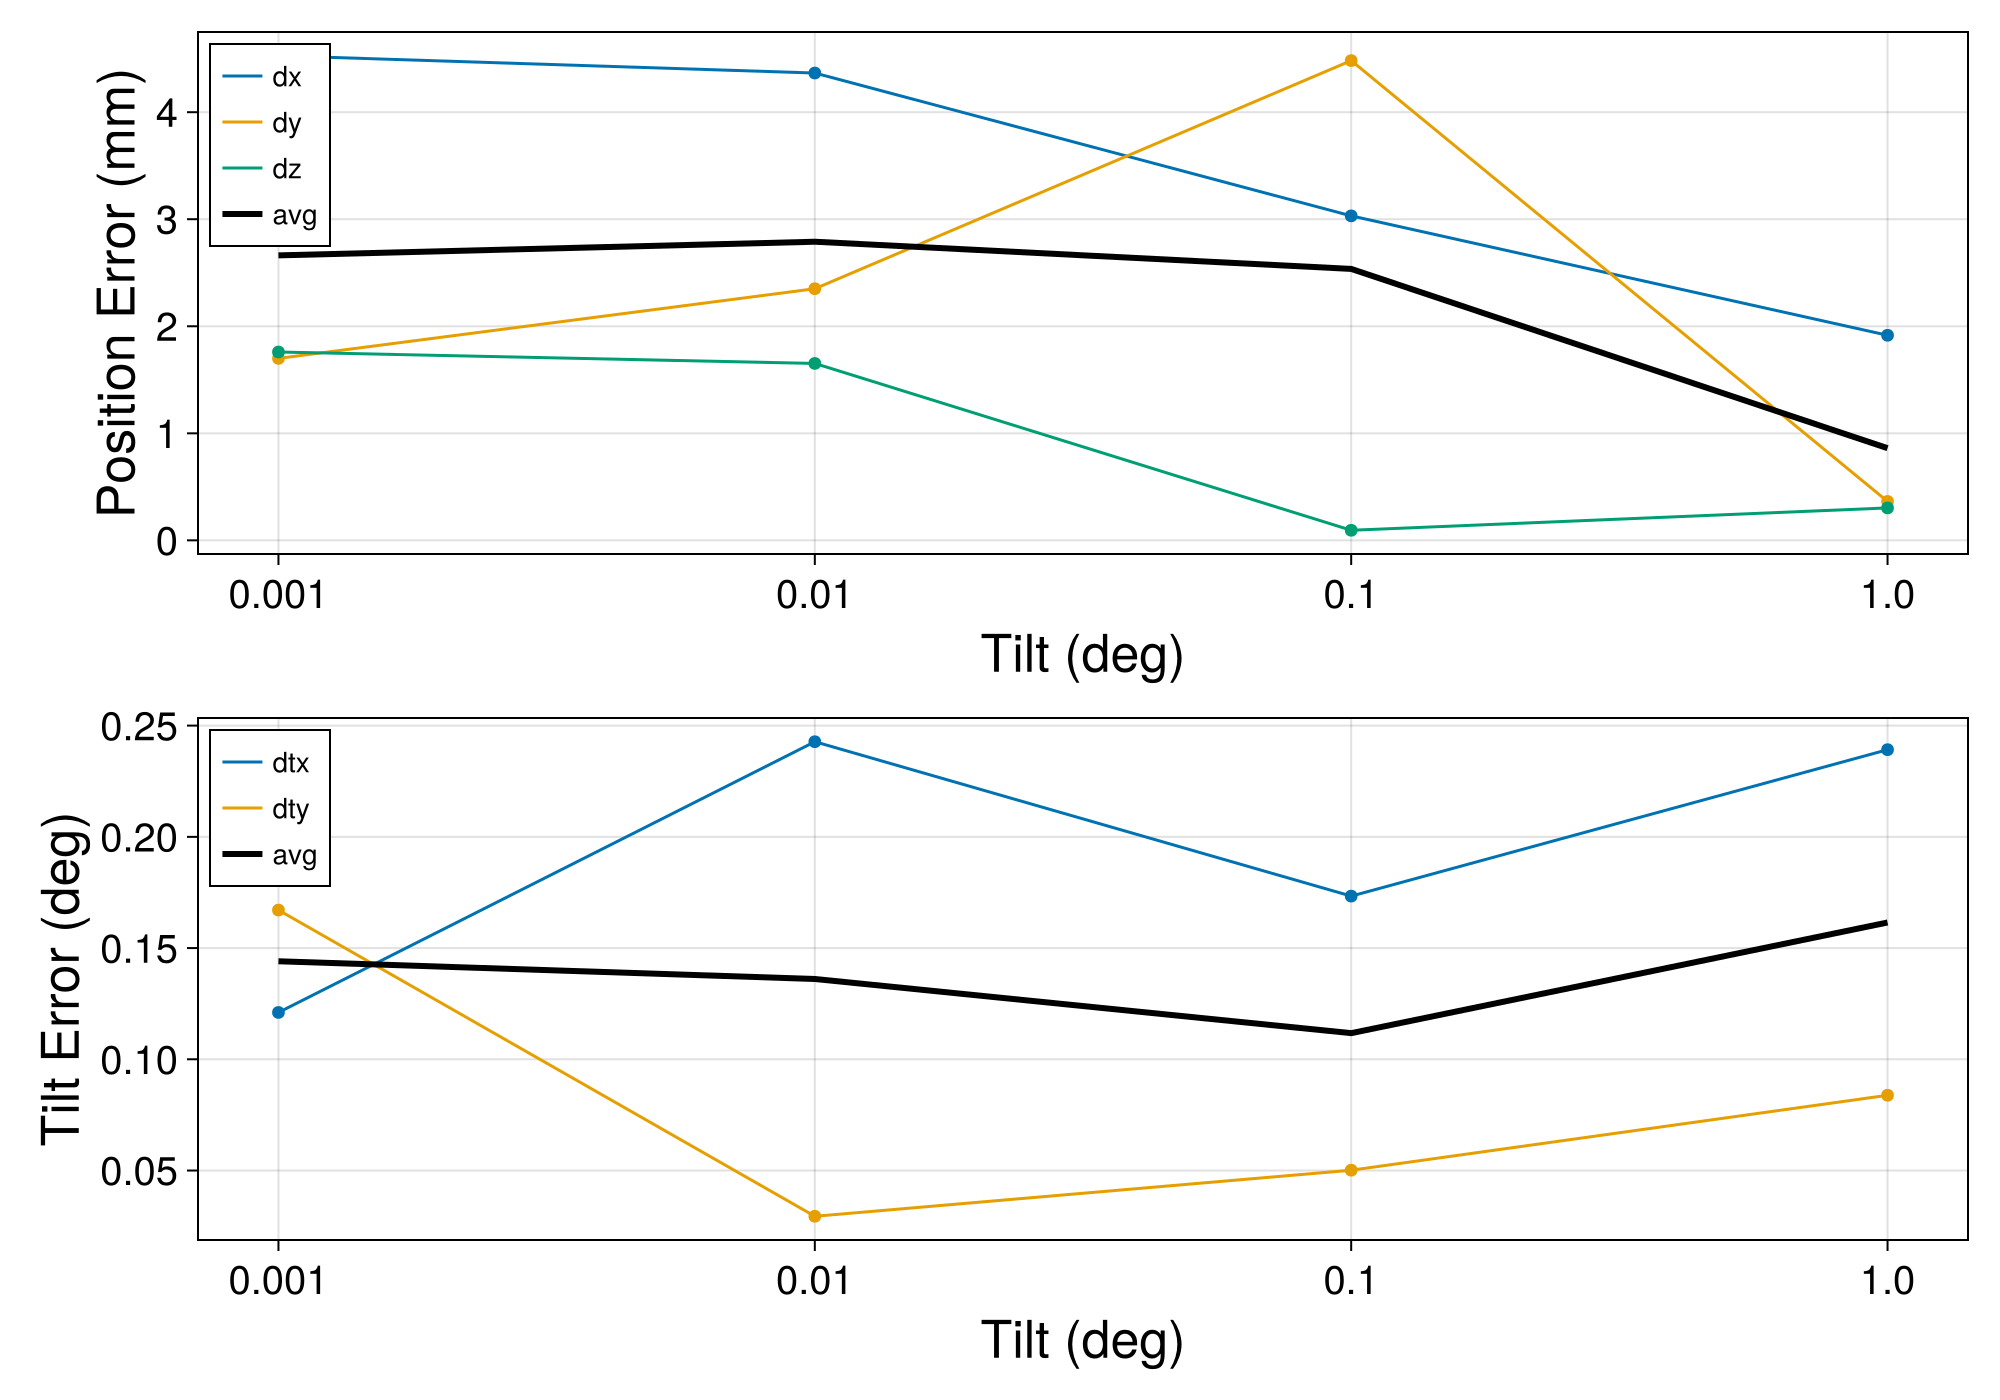

In [16]:
using CairoMakie

tilts = [.001, .01, .1, 1]

dx_mm  = Float64[]
dy_mm  = Float64[]
dz_mm  = Float64[]
dtx_deg = Float64[]
dty_deg = Float64[]

for tilt in tilts
    dr, phys, fld, ls = run_scan(
        shift_x=0,
        shift_y=0,
        shift_z=0,
        tilt_x_deg=tilt,
        tilt_y_deg=tilt,
        hall_r_inner_frac= 0.40,
        hall_r_outer_frac= 0.50,
        add_noise_frac = 0.01,
    )

    push!(dx_mm,  abs(fld.x0 - phys.x0 - 0) * 1e3)
    push!(dy_mm,  abs(fld.y0 - phys.y0 - 0) * 1e3)
    push!(dz_mm,  abs(fld.z0 - phys.z0 - 0) * 1e3)
    push!(dtx_deg, abs(fld.tilt_x - phys.tilt_x - tilt))
    push!(dty_deg, abs(fld.tilt_y - phys.tilt_y - tilt))
end

x_mm = tilts # .* 1e3

pos_avg  = (dx_mm .+ dy_mm .+ dz_mm) ./ 3
tilt_avg = (dtx_deg .+ dty_deg) ./ 2

fig = Figure(resolution=(1000,700))

ax1 = Axis(fig[1,1],
    xlabel="Tilt (deg)",
    ylabel="Position Error (mm)",
    xscale=log10,
    xtickformat=x -> string.(round.(x; digits=6))
)

ax2 = Axis(fig[2,1],
    xlabel="Tilt (deg)",
    ylabel="Tilt Error (deg)",
    xscale=log10,
    xtickformat=x -> string.(round.(x; digits=6))
)

ax1.xlabelsize=ax1.ylabelsize=ax2.xlabelsize=ax2.ylabelsize=26
ax1.xticklabelsize=ax1.yticklabelsize=ax2.xticklabelsize=ax2.yticklabelsize=20

# position components
lines!(ax1, x_mm, dx_mm, label="dx")
scatter!(ax1, x_mm, dx_mm)

lines!(ax1, x_mm, dy_mm, label="dy")
scatter!(ax1, x_mm, dy_mm)

lines!(ax1, x_mm, dz_mm, label="dz")
scatter!(ax1, x_mm, dz_mm)

lines!(ax1, x_mm, pos_avg, label="avg", linewidth=3, color=:black)


# tilt components
lines!(ax2, x_mm, dtx_deg, label="dtx")
scatter!(ax2, x_mm, dtx_deg)

lines!(ax2, x_mm, dty_deg, label="dty")
scatter!(ax2, x_mm, dty_deg)

lines!(ax2, x_mm, tilt_avg, label="avg", linewidth=3, color=:black)

axislegend(ax1; position=:lt)
axislegend(ax2; position=:lt)
fig

┌ Warning: Found `resolution` in the theme when creating a `Scene`. The `resolution` keyword for `Scene`s and `Figure`s has been deprecated. Use `Figure(; size = ...` or `Scene(; size = ...)` instead, which better reflects that this is a unitless size and not a pixel resolution. The key could also come from `set_theme!` calls or related theming functions.
└ @ Makie /Users/bursche/.julia/packages/Makie/kJl0u/src/scenes.jl:264


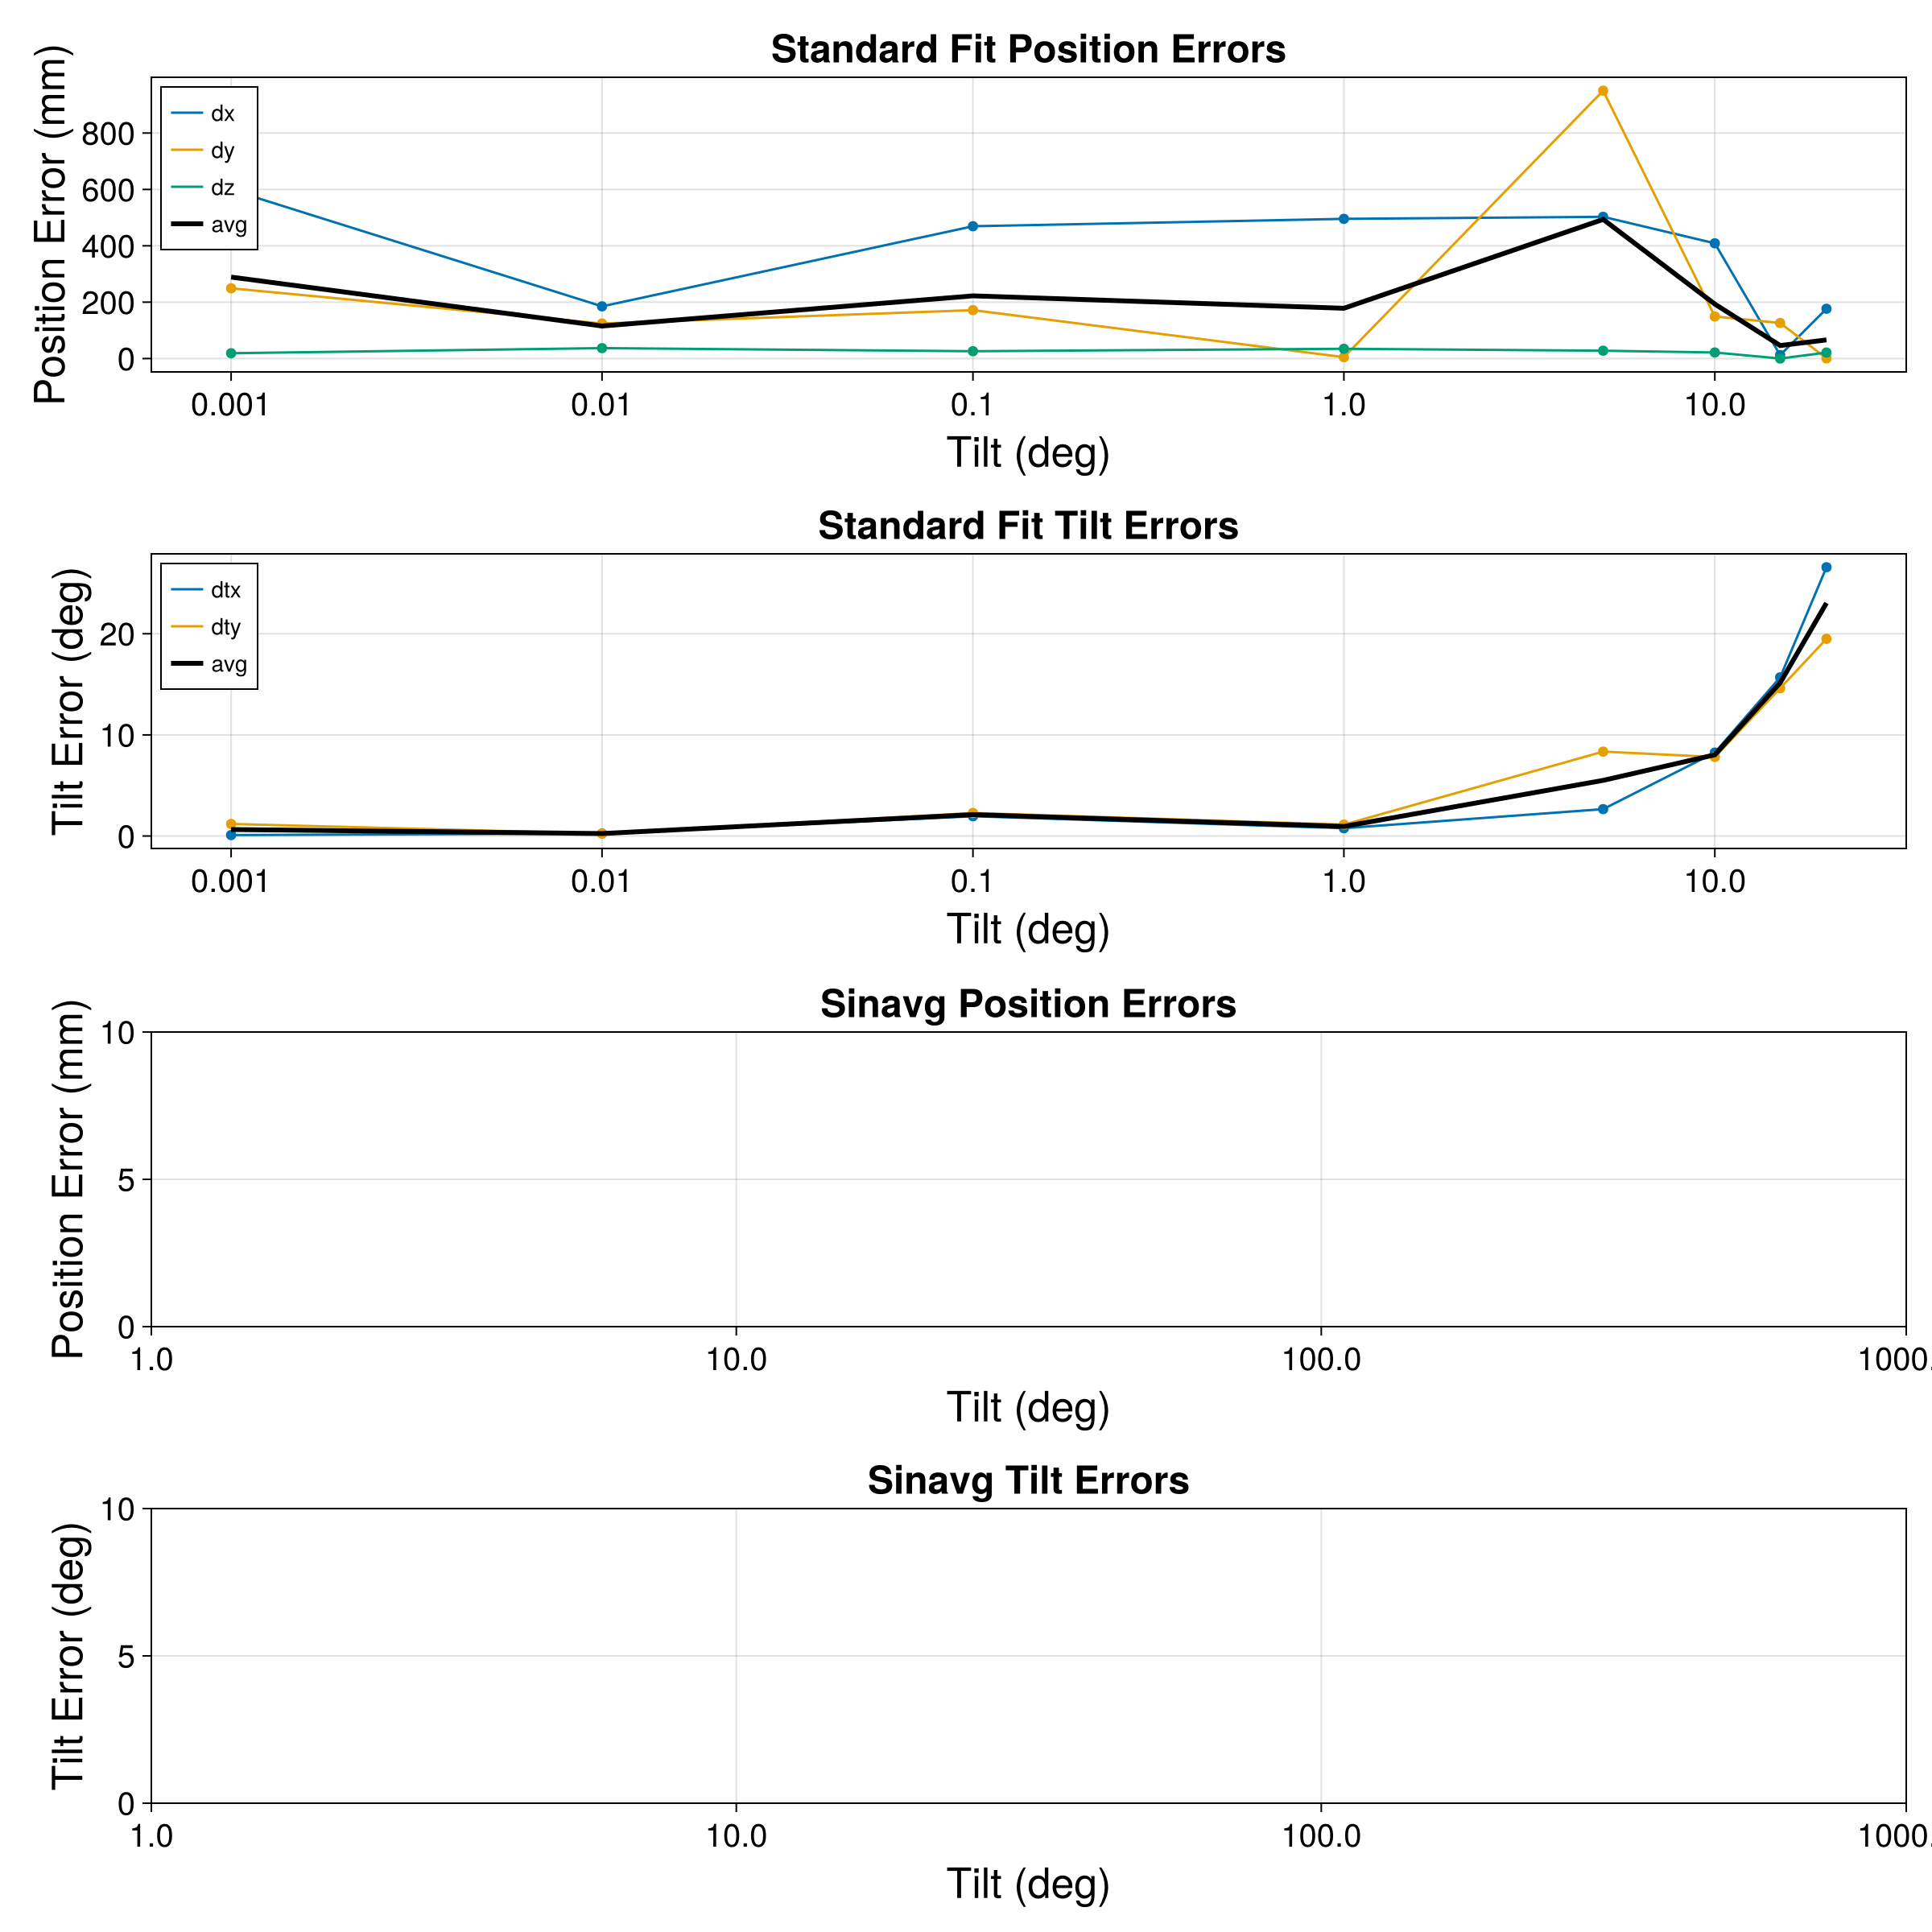

In [ ]:
using CairoMakie

tilts = [.001, .01, .1, 1, 5, 10, 15, 20]

# ============================================================
# Standard fit errors
# ============================================================

dx_mm   = Float64[]
dy_mm   = Float64[]
dz_mm   = Float64[]
dtx_deg = Float64[]
dty_deg = Float64[]

# ============================================================
# Sinavg fit errors
# ============================================================

dxs_mm   = Float64[]
dys_mm   = Float64[]
dzs_mm   = Float64[]
dtxs_deg = Float64[]
dtys_deg = Float64[]

for tilt in tilts

    dr, phys, fld, ls = run_scan(
        shift_x=0,
        shift_y=0,
        shift_z=0,

        tilt_x_deg=tilt,
        tilt_y_deg=tilt,

        hall_r_inner_frac = 0.50,
        hall_r_outer_frac = 0.50,

        add_noise_frac = 0.5,
    )

    # ========================================================
    # Standard fit
    # ========================================================

    push!(dx_mm, abs(fld.x0 - phys.x0) * 1e3)
    push!(dy_mm, abs(fld.y0 - phys.y0) * 1e3)
    push!(dz_mm, abs(fld.z0 - phys.z0) * 1e3)

    push!(dtx_deg, abs(fld.tilt_x - phys.tilt_x - tilt))
    push!(dty_deg, abs(fld.tilt_y - phys.tilt_y - tilt))

    # ========================================================
    # Sinavg fit
    # ========================================================

    sinavg = ls.field_analysis.sinavg

    push!(dxs_mm, abs(sinavg.x0 - phys.x0) * 1e3)
    push!(dys_mm, abs(sinavg.y0 - phys.y0) * 1e3)
    push!(dzs_mm, abs(sinavg.z0 - phys.z0) * 1e3)

    push!(dtxs_deg, abs(sinavg.tilt_x - phys.tilt_x - tilt))
    push!(dtys_deg, abs(sinavg.tilt_y - phys.tilt_y - tilt))
end

x_mm = tilts

# ============================================================
# Averages
# ============================================================

pos_avg  = (dx_mm  .+ dy_mm  .+ dz_mm) ./ 3
tilt_avg = (dtx_deg .+ dty_deg) ./ 2

pos_avg_s  = (dxs_mm  .+ dys_mm  .+ dzs_mm) ./ 3
tilt_avg_s = (dtxs_deg .+ dtys_deg) ./ 2

# ============================================================
# Figure
# ============================================================

fig = Figure(resolution=(1200, 1200))

# ============================================================
# Standard fit axes
# ============================================================

ax1 = Axis(
    fig[1,1],
    xlabel="Tilt (deg)",
    ylabel="Position Error (mm)",
    xscale=log10,
    xtickformat=x -> string.(round.(x; digits=6)),
    title="Standard Fit Position Errors"
)

ax2 = Axis(
    fig[2,1],
    xlabel="Tilt (deg)",
    ylabel="Tilt Error (deg)",
    xscale=log10,
    xtickformat=x -> string.(round.(x; digits=6)),
    title="Standard Fit Tilt Errors"
)

# ============================================================
# Sinavg axes
# ============================================================

ax3 = Axis(
    fig[3,1],
    xlabel="Tilt (deg)",
    ylabel="Position Error (mm)",
    xscale=log10,
    xtickformat=x -> string.(round.(x; digits=6)),
    title="Sinavg Position Errors"
)

ax4 = Axis(
    fig[4,1],
    xlabel="Tilt (deg)",
    ylabel="Tilt Error (deg)",
    xscale=log10,
    xtickformat=x -> string.(round.(x; digits=6)),
    title="Sinavg Tilt Errors"
)

# ============================================================
# Font sizes
# ============================================================

for ax in (ax1, ax2)#, ax3, ax4)

    ax.xlabelsize = 26
    ax.ylabelsize = 26

    ax.xticklabelsize = 20
    ax.yticklabelsize = 20

    ax.titlesize = 24
end

# ============================================================
# Standard position
# ============================================================

lines!(ax1, x_mm, dx_mm, label="dx")
scatter!(ax1, x_mm, dx_mm)

lines!(ax1, x_mm, dy_mm, label="dy")
scatter!(ax1, x_mm, dy_mm)

lines!(ax1, x_mm, dz_mm, label="dz")
scatter!(ax1, x_mm, dz_mm)

lines!(
    ax1,
    x_mm,
    pos_avg,
    label="avg",
    linewidth=3,
    color=:black
)

# ============================================================
# Standard tilt
# ============================================================

lines!(ax2, x_mm, dtx_deg, label="dtx")
scatter!(ax2, x_mm, dtx_deg)

lines!(ax2, x_mm, dty_deg, label="dty")
scatter!(ax2, x_mm, dty_deg)

lines!(
    ax2,
    x_mm,
    tilt_avg,
    label="avg",
    linewidth=3,
    color=:black
)

# ============================================================
# Sinavg position
# ============================================================
"""
lines!(ax3, x_mm, dxs_mm, label="dx")
scatter!(ax3, x_mm, dxs_mm)

lines!(ax3, x_mm, dys_mm, label="dy")
scatter!(ax3, x_mm, dys_mm)

lines!(ax3, x_mm, dzs_mm, label="dz")
scatter!(ax3, x_mm, dzs_mm)

lines!(
    ax3,
    x_mm,
    pos_avg_s,
    label="avg",
    linewidth=3,
    color=:black
)

# ============================================================
# Sinavg tilt
# ============================================================

lines!(ax4, x_mm, dtxs_deg, label="dtx")
scatter!(ax4, x_mm, dtxs_deg)

lines!(ax4, x_mm, dtys_deg, label="dty")
scatter!(ax4, x_mm, dtys_deg)

lines!(
    ax4,
    x_mm,
    tilt_avg_s,
    label="avg",
    linewidth=3,
    color=:black
)
"""
# ============================================================
# Legends
# ============================================================

axislegend(ax1; position=:lt)
axislegend(ax2; position=:lt)
#axislegend(ax3; position=:lt)
#axislegend(ax4; position=:lt)

fig

┌ Warning: Found `resolution` in the theme when creating a `Scene`. The `resolution` keyword for `Scene`s and `Figure`s has been deprecated. Use `Figure(; size = ...` or `Scene(; size = ...)` instead, which better reflects that this is a unitless size and not a pixel resolution. The key could also come from `set_theme!` calls or related theming functions.
└ @ Makie /Users/bursche/.julia/packages/Makie/kJl0u/src/scenes.jl:264


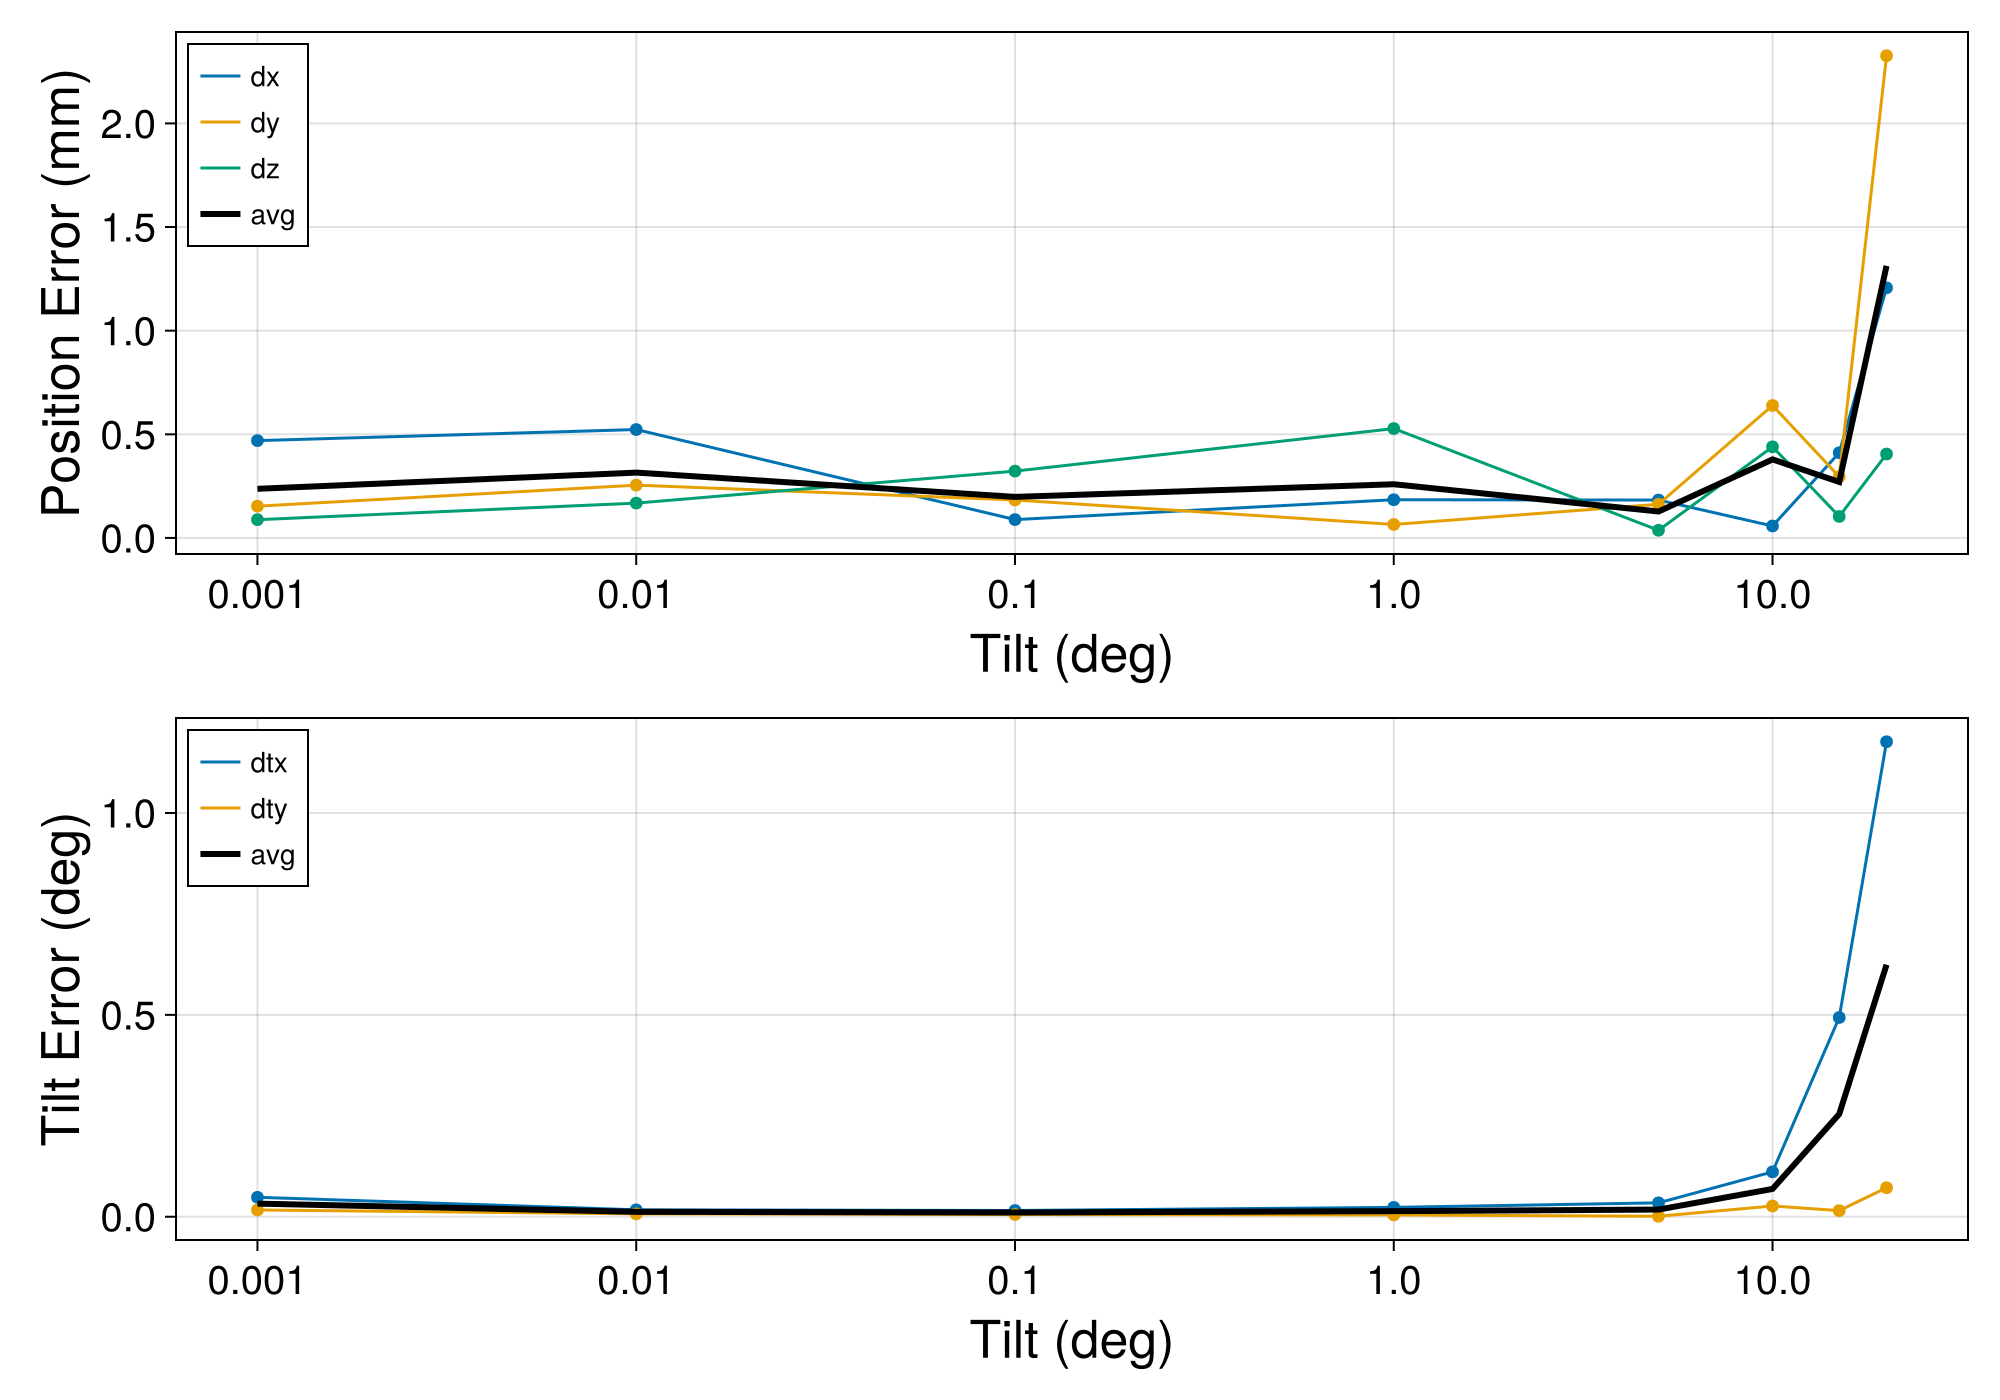

In [16]:
using CairoMakie

tilts = [0.001, 0.01, 0.1, 1, 5, 10, 15, 20]

# ============================================================
# Errors (same structure as shift scan, but tilt sweep)
# ============================================================

dx_mm   = Float64[]
dy_mm   = Float64[]
dz_mm   = Float64[]
dtx_deg = Float64[]
dty_deg = Float64[]

for tilt in tilts

    dr, phys, fld = run_scan(
        shift_x = 0.0,
        shift_y = 0.0,
        shift_z = 0.0,

        tilt_x_deg = tilt,
        tilt_y_deg = tilt,

        add_noise_frac = 0.001,
    )

    push!(dx_mm,   abs(fld.x0 - phys.x0) * 1e3)
    push!(dy_mm,   abs(fld.y0 - phys.y0) * 1e3)
    push!(dz_mm,   abs(fld.z0 - phys.z0) * 1e3)

    push!(dtx_deg, abs(fld.tilt_x - phys.tilt_x - tilt))
    push!(dty_deg, abs(fld.tilt_y - phys.tilt_y - tilt))
end

x = tilts

pos_avg  = (dx_mm .+ dy_mm .+ dz_mm) ./ 3
tilt_avg = (dtx_deg .+ dty_deg) ./ 2

# ============================================================
# Figure (same layout as original shift version)
# ============================================================

fig = Figure(resolution=(1000,700))

ax1 = Axis(fig[1,1],
    xlabel="Tilt (deg)",
    ylabel="Position Error (mm)",
    xscale=log10,
    xtickformat=x -> string.(round.(x; digits=6))
)

ax2 = Axis(fig[2,1],
    xlabel="Tilt (deg)",
    ylabel="Tilt Error (deg)",
    xscale=log10,
    xtickformat=x -> string.(round.(x; digits=6))
)

ax1.xlabelsize = ax1.ylabelsize = ax2.xlabelsize = ax2.ylabelsize = 26
ax1.xticklabelsize = ax1.yticklabelsize = ax2.xticklabelsize = ax2.yticklabelsize = 20

# ============================================================
# Position components
# ============================================================

lines!(ax1, x, dx_mm, label="dx")
scatter!(ax1, x, dx_mm)

lines!(ax1, x, dy_mm, label="dy")
scatter!(ax1, x, dy_mm)

lines!(ax1, x, dz_mm, label="dz")
scatter!(ax1, x, dz_mm)

lines!(ax1, x, pos_avg, label="avg", linewidth=3, color=:black)

# ============================================================
# Tilt components
# ============================================================

lines!(ax2, x, dtx_deg, label="dtx")
scatter!(ax2, x, dtx_deg)

lines!(ax2, x, dty_deg, label="dty")
scatter!(ax2, x, dty_deg)

lines!(ax2, x, tilt_avg, label="avg", linewidth=3, color=:black)

axislegend(ax1; position=:lt)
axislegend(ax2; position=:lt)

fig

┌ Warning: Found `resolution` in the theme when creating a `Scene`. The `resolution` keyword for `Scene`s and `Figure`s has been deprecated. Use `Figure(; size = ...` or `Scene(; size = ...)` instead, which better reflects that this is a unitless size and not a pixel resolution. The key could also come from `set_theme!` calls or related theming functions.
└ @ Makie /Users/bursche/.julia/packages/Makie/kJl0u/src/scenes.jl:264


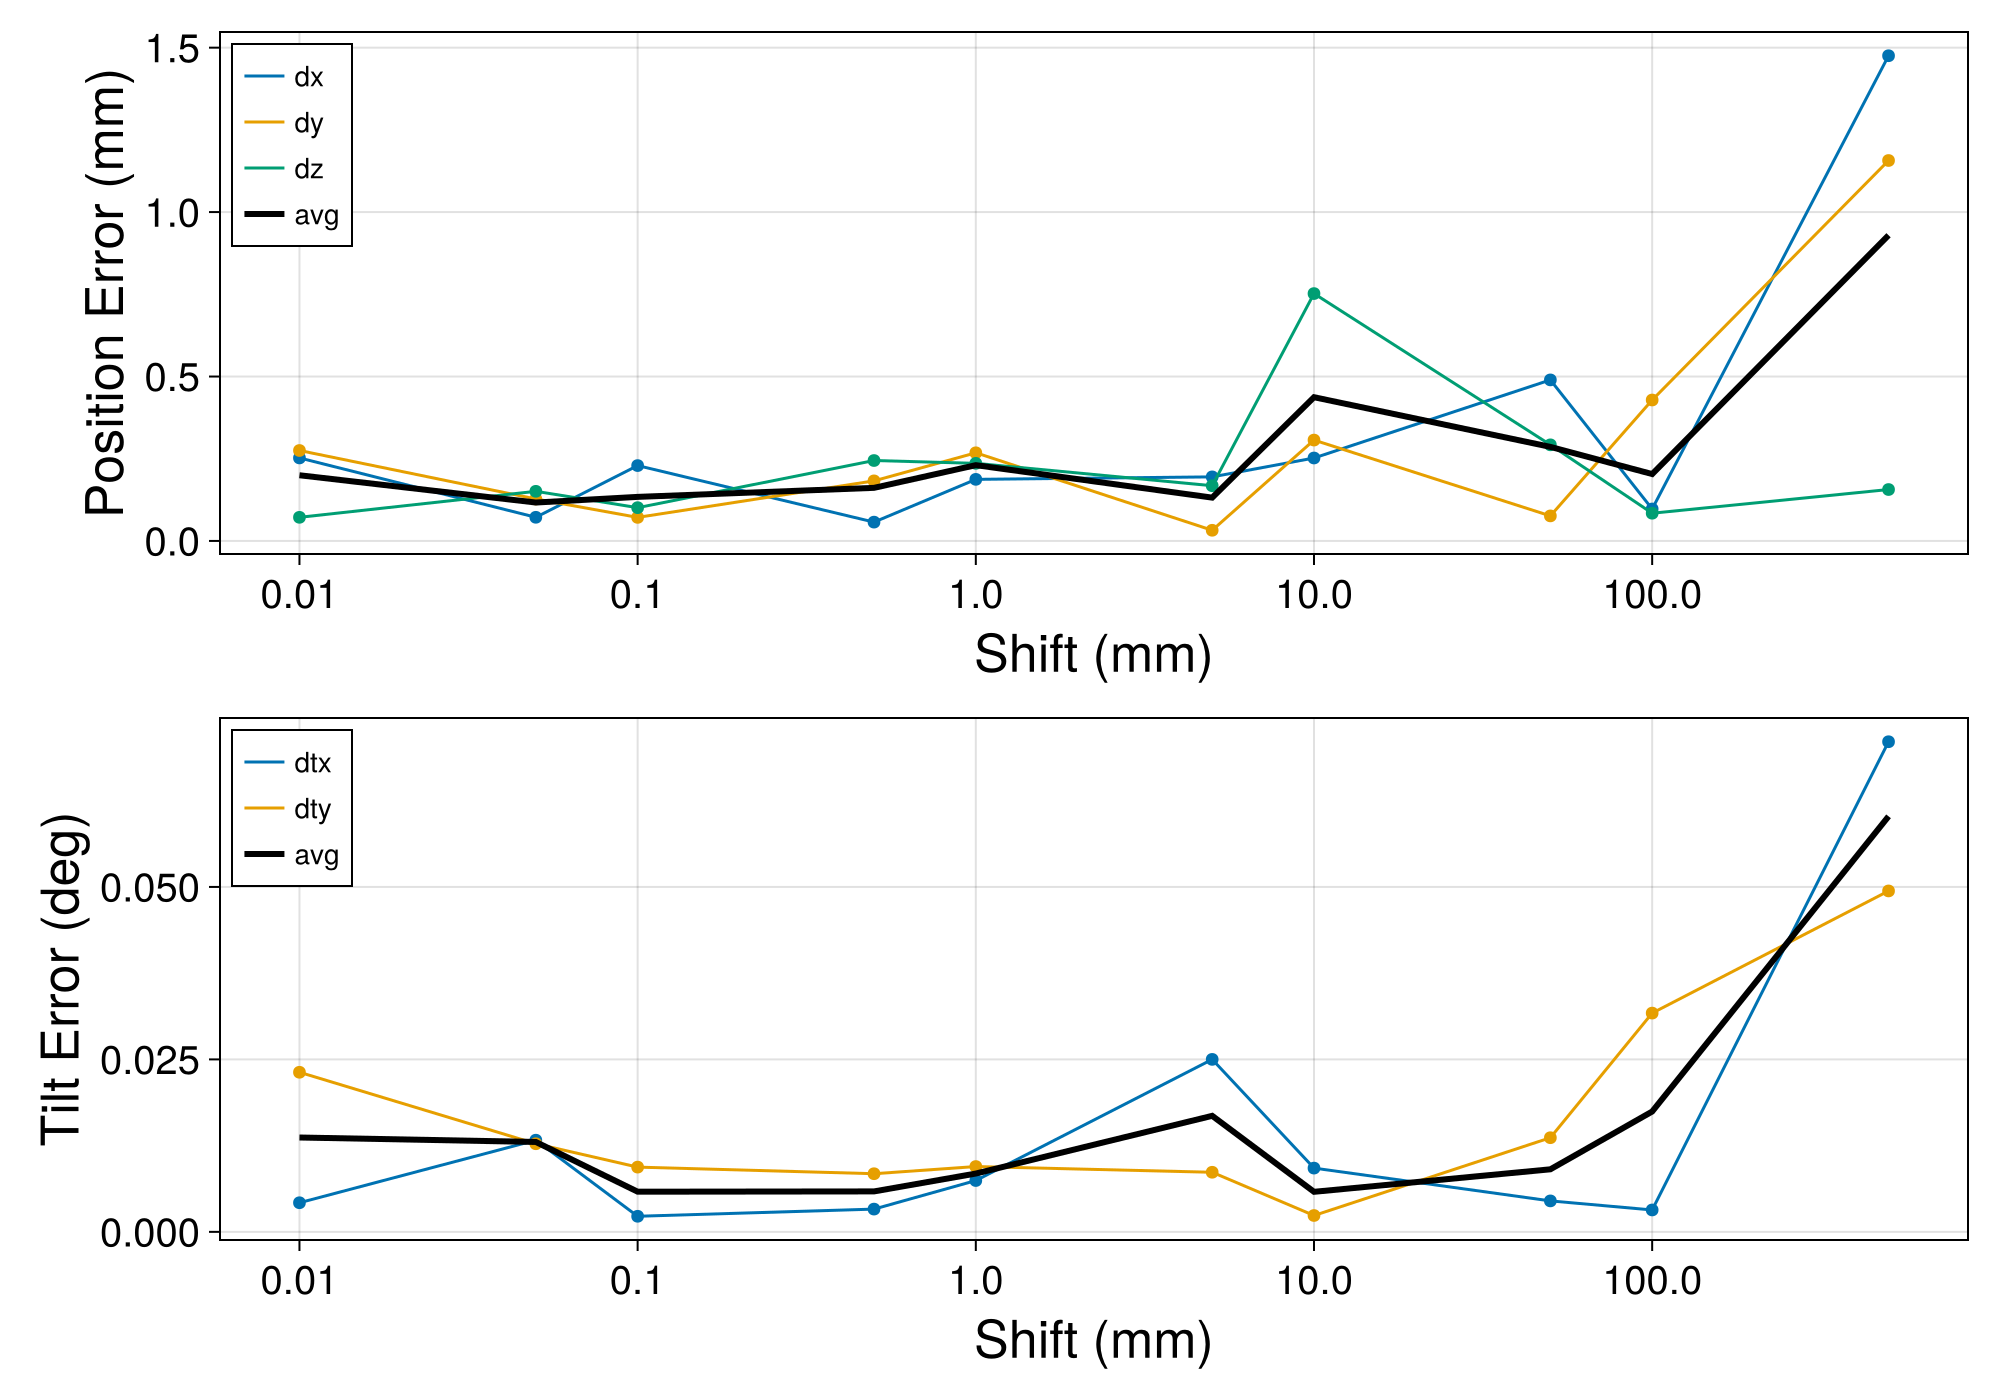

In [10]:
using CairoMakie

shifts = [1e-5, 5e-5, 1e-4, 5e-4, 1e-3, 5e-3, 1e-2, 5e-2, 1e-1, 5e-1]

dx_mm  = Float64[]
dy_mm  = Float64[]
dz_mm  = Float64[]
dtx_deg = Float64[]
dty_deg = Float64[]

for shift in shifts
    dr, phys, fld = run_scan(
        shift_x=shift,
        shift_y=shift,
        shift_z=shift,
        tilt_x_deg=0.0,
        add_noise_frac = 0.001,
    )

    push!(dx_mm,  abs(fld.x0 - phys.x0 - shift) * 1e3)
    push!(dy_mm,  abs(fld.y0 - phys.y0 - shift) * 1e3)
    push!(dz_mm,  abs(fld.z0 - phys.z0 - shift) * 1e3)
    push!(dtx_deg, abs(fld.tilt_x - phys.tilt_x))
    push!(dty_deg, abs(fld.tilt_y - phys.tilt_y))
end

x_mm = shifts .* 1e3

pos_avg  = (dx_mm .+ dy_mm .+ dz_mm) ./ 3
tilt_avg = (dtx_deg .+ dty_deg) ./ 2

fig = Figure(resolution=(1000,700))

ax1 = Axis(fig[1,1],
    xlabel="Shift (mm)",
    ylabel="Position Error (mm)",
    xscale=log10,
    xtickformat=x -> string.(round.(x; digits=6))
)

ax2 = Axis(fig[2,1],
    xlabel="Shift (mm)",
    ylabel="Tilt Error (deg)",
    xscale=log10,
    xtickformat=x -> string.(round.(x; digits=6))
)

ax1.xlabelsize=ax1.ylabelsize=ax2.xlabelsize=ax2.ylabelsize=26
ax1.xticklabelsize=ax1.yticklabelsize=ax2.xticklabelsize=ax2.yticklabelsize=20

# position components
lines!(ax1, x_mm, dx_mm, label="dx")
scatter!(ax1, x_mm, dx_mm)

lines!(ax1, x_mm, dy_mm, label="dy")
scatter!(ax1, x_mm, dy_mm)

lines!(ax1, x_mm, dz_mm, label="dz")
scatter!(ax1, x_mm, dz_mm)

lines!(ax1, x_mm, pos_avg, label="avg", linewidth=3, color=:black)


# tilt components
lines!(ax2, x_mm, dtx_deg, label="dtx")
scatter!(ax2, x_mm, dtx_deg)

lines!(ax2, x_mm, dty_deg, label="dty")
scatter!(ax2, x_mm, dty_deg)

lines!(ax2, x_mm, tilt_avg, label="avg", linewidth=3, color=:black)

axislegend(ax1; position=:lt)
axislegend(ax2; position=:lt)
fig

┌ Warning: Found `resolution` in the theme when creating a `Scene`. The `resolution` keyword for `Scene`s and `Figure`s has been deprecated. Use `Figure(; size = ...` or `Scene(; size = ...)` instead, which better reflects that this is a unitless size and not a pixel resolution. The key could also come from `set_theme!` calls or related theming functions.
└ @ Makie /Users/bursche/.julia/packages/Makie/kJl0u/src/scenes.jl:264


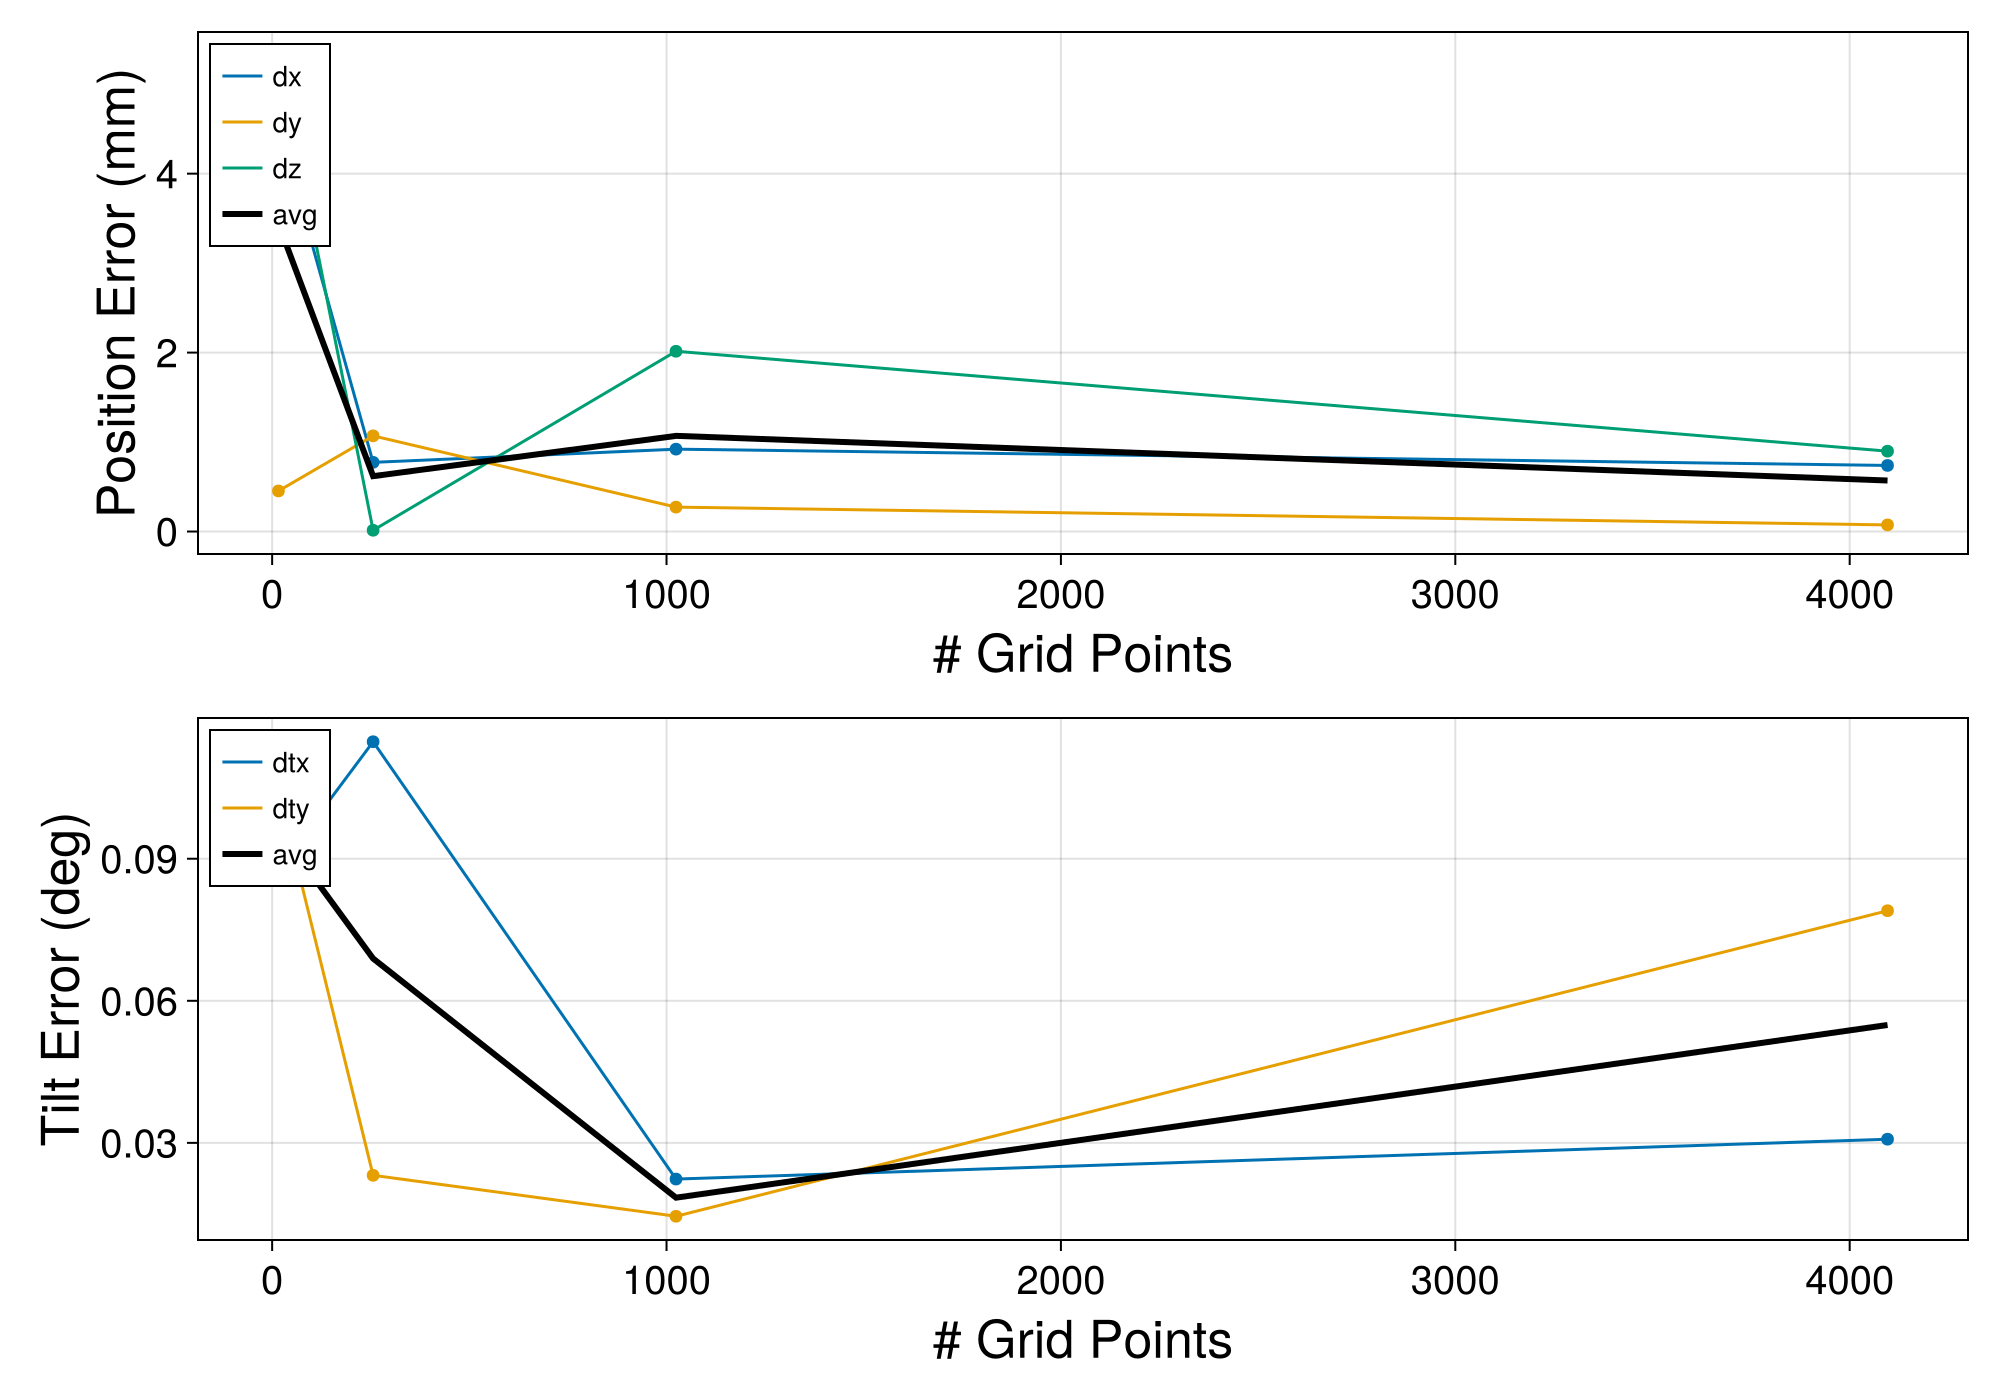

In [196]:
using CairoMakie

Ns = [ 4, 16, 32, 64 ]

dx_mm  = Float64[]
dy_mm  = Float64[]
dz_mm  = Float64[]
dtx_deg = Float64[]
dty_deg = Float64[]

for N in Ns
    dr, phys, fld = run_scan(
        shift_x=0.01,
        shift_y=0.01,
        shift_z=0.01,
        tilt_x_deg=1,
        tilt_y_deg=1,
        n_phi_inner=N,
        n_z_inner=N,
        add_noise_frac = 0.005,
    )

    push!(dx_mm,  abs(fld.x0 - phys.x0 - 0.01) * 1e3)
    push!(dy_mm,  abs(fld.y0 - phys.y0 - 0.01) * 1e3)
    push!(dz_mm,  abs(fld.z0 - phys.z0 - 0.01) * 1e3)
    push!(dtx_deg, abs(fld.tilt_x - phys.tilt_x - 1))
    push!(dty_deg, abs(fld.tilt_y - phys.tilt_y - 1))
end

x = Ns.^2

# averages per curve
pos_avg  = [(dx_mm .+ dy_mm .+ dz_mm) ./ 3]
tilt_avg = [(dtx_deg .+ dty_deg) ./ 2]

pos_avg  = vec(pos_avg[1])
tilt_avg = vec(tilt_avg[1])

fig = Figure(resolution=(1000,700))

ax1 = Axis(fig[1,1],
    xlabel="# Grid Points",
    ylabel="Position Error (mm)"
)

ax2 = Axis(fig[2,1],
    xlabel="# Grid Points",
    ylabel="Tilt Error (deg)"
)

ax1.xlabelsize=ax1.ylabelsize=ax2.xlabelsize=ax2.ylabelsize=26
ax1.xticklabelsize=ax1.yticklabelsize=ax2.xticklabelsize=ax2.yticklabelsize=20

# position components
lines!(ax1, x, dx_mm, label="dx")
scatter!(ax1, x, dx_mm)

lines!(ax1, x, dy_mm, label="dy")
scatter!(ax1, x, dy_mm)

lines!(ax1, x, dz_mm, label="dz")
scatter!(ax1, x, dz_mm)

lines!(ax1, x, pos_avg, label="avg", linewidth=3, color=:black)


# tilt components
lines!(ax2, x, dtx_deg, label="dtx")
scatter!(ax2, x, dtx_deg)

lines!(ax2, x, dty_deg, label="dty")
scatter!(ax2, x, dty_deg)

lines!(ax2, x, tilt_avg, label="avg", linewidth=3, color=:black)

axislegend(ax1; position=:lt)
axislegend(ax2; position=:lt)
fig

┌ Warning: Found `resolution` in the theme when creating a `Scene`. The `resolution` keyword for `Scene`s and `Figure`s has been deprecated. Use `Figure(; size = ...` or `Scene(; size = ...)` instead, which better reflects that this is a unitless size and not a pixel resolution. The key could also come from `set_theme!` calls or related theming functions.
└ @ Makie /Users/bursche/.julia/packages/Makie/kJl0u/src/scenes.jl:264


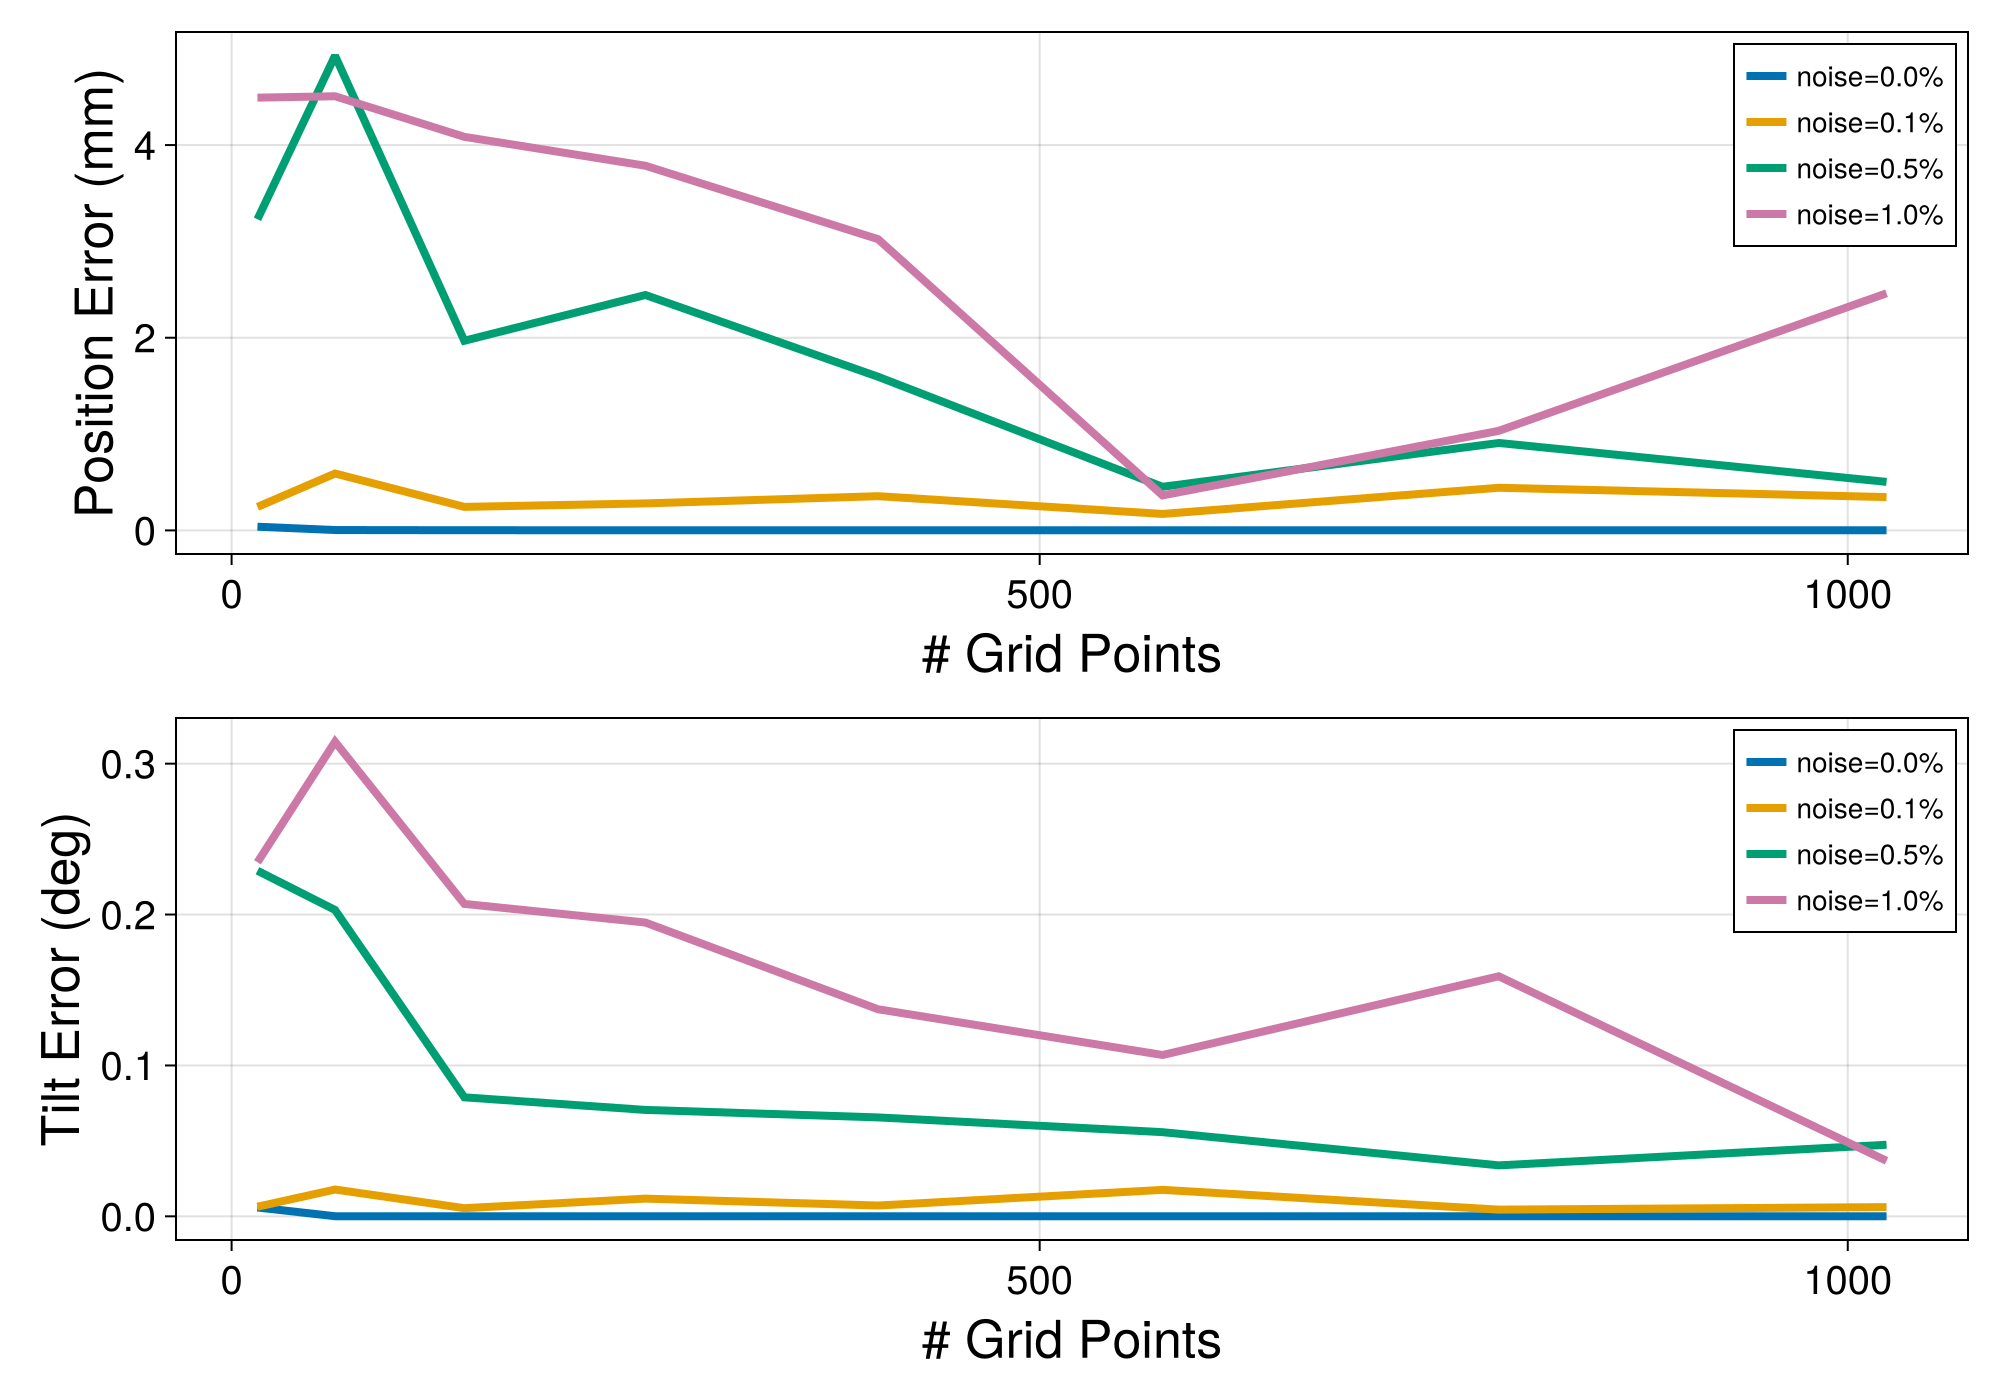

In [24]:
using CairoMakie

Ns = [4, 8, 12, 16,20,  24, 28, 32,]
noise_fracs = [0.0, 0.001, 0.005, 0.01]

x = Ns .^ 2

# ------------------------------------------------------------
# Storage: noise curves
# ------------------------------------------------------------

pos_avg_curves  = Vector{Vector{Float64}}()
tilt_avg_curves = Vector{Vector{Float64}}()

dx_curves  = Vector{Vector{Float64}}()
dy_curves  = Vector{Vector{Float64}}()
dz_curves  = Vector{Vector{Float64}}()

dtx_curves = Vector{Vector{Float64}}()
dty_curves = Vector{Vector{Float64}}()

for nf in noise_fracs

    dx_mm   = Float64[]
    dy_mm   = Float64[]
    dz_mm   = Float64[]
    dtx_deg = Float64[]
    dty_deg = Float64[]

    for N in Ns

        dr, phys, fld = run_scan(
            shift_x=0.03,
            shift_y=0.03,
            shift_z=0.03,

            tilt_x_deg=.5,
            tilt_y_deg=.5,
            hall_r_inner_frac = 0.40,
            hall_r_outer_frac = 0.50,
            

            n_phi_inner=N,
            n_z_inner=N,

            add_noise_frac=nf,
        )

        push!(dx_mm,  abs(fld.x0 - phys.x0 - 0.03) * 1e3)
        push!(dy_mm,  abs(fld.y0 - phys.y0 - 0.03) * 1e3)
        push!(dz_mm,  abs(fld.z0 - phys.z0 - 0.03) * 1e3)

        push!(dtx_deg, abs(fld.tilt_x - phys.tilt_x - .5))
        push!(dty_deg, abs(fld.tilt_y - phys.tilt_y - .5))
    end

    push!(dx_curves, dx_mm)
    push!(dy_curves, dy_mm)
    push!(dz_curves, dz_mm)

    push!(dtx_curves, dtx_deg)
    push!(dty_curves, dty_deg)

    push!(pos_avg_curves, (dx_mm .+ dy_mm .+ dz_mm) ./ 3)
    push!(tilt_avg_curves, (dtx_deg .+ dty_deg) ./ 2)
end

# ------------------------------------------------------------
# Plot
# ------------------------------------------------------------

fig = Figure(resolution=(1000, 700))

ax1 = Axis(fig[1, 1],
    xlabel="# Grid Points",
    ylabel="Position Error (mm)"
)

ax2 = Axis(fig[2, 1],
    xlabel="# Grid Points",
    ylabel="Tilt Error (deg)"
)

ax1.xlabelsize = ax2.xlabelsize = 26
ax1.ylabelsize = ax2.ylabelsize = 26
ax1.xticklabelsize = ax2.xticklabelsize = 20
ax1.yticklabelsize = ax2.yticklabelsize = 20

# ------------------------------------------------------------
# Position: ONLY averages shown, multiple noise curves
# ------------------------------------------------------------

for (i, nf) in enumerate(noise_fracs)
    lines!(ax1, x, pos_avg_curves[i], label="noise=$(nf*100)%",linewidth=4)
end

#lines!(ax1, x, pos_avg_curves[3], linewidth=3, color=:black, label="ref avg")

# ------------------------------------------------------------
# Tilt: ONLY averages shown, multiple noise curves
# ------------------------------------------------------------

for (i, nf) in enumerate(noise_fracs)
    lines!(ax2, x, tilt_avg_curves[i], label="noise=$(nf*100)%", linewidth=4)
end

#lines!(ax2, x, tilt_avg_curves[3], linewidth=3, color=:black, label="ref avg")

axislegend(ax1; position=:rt)
axislegend(ax2; position=:rt)

fig

In [1]:
println("Done with all runs.")

Done with all runs.


In [ ]:
using CairoMakie

# ============================================================
# Fixed resolution
# ============================================================

N = 24
noise_frac = 0.001

inner_fracs = range(0.0, 2.0, length=5)
outer_fracs = range(0.0, 2.0, length=5)

# ============================================================
# Storage
# ============================================================

pos_avg_grid  = Array{Union{Float64, Missing}}(missing, length(inner_fracs), length(outer_fracs))
tilt_avg_grid = Array{Union{Float64, Missing}}(missing, length(inner_fracs), length(outer_fracs))

# ============================================================
# Sweep
# ============================================================

for (i, r_in) in enumerate(inner_fracs)
    for (j, r_out) in enumerate(outer_fracs)

        try
            dr, phys, fld, ls = run_scan(
                shift_x=0.01,
                shift_y=0.01,
                shift_z=0.01,

                tilt_x_deg=1,
                tilt_y_deg=1,

                hall_r_inner_frac = r_in,
                hall_r_outer_frac = r_out,

                n_phi_inner = N,
                n_z_inner   = N,

                add_noise_frac = noise_frac,
            )

            dx = abs(fld.x0 - phys.x0 - 0.01) * 1e3
            dy = abs(fld.y0 - phys.y0 - 0.01) * 1e3
            dz = abs(fld.z0 - phys.z0 - 0.01) * 1e3

            dtx = abs(fld.tilt_x - phys.tilt_x - 1)
            dty = abs(fld.tilt_y - phys.tilt_y - 1)

            pos_avg_grid[i, j]  = (dx + dy + dz) / 3
            tilt_avg_grid[i, j] = (dtx + dty) / 2

        catch e
            @warn "Simulation failed at r_in=$r_in, r_out=$r_out" exception=e
            pos_avg_grid[i, j]  = missing
            tilt_avg_grid[i, j] = missing
        end
    end
end

# ============================================================
# Convert for plotting (flatten valid entries)
# ============================================================

xs = Float64[]
ys = Float64[]
zs = Float64[]

xt = Float64[]
yt = Float64[]
zt = Float64[]

for i in eachindex(inner_fracs), j in eachindex(outer_fracs)

    if !ismissing(pos_avg_grid[i, j])
        push!(xs, inner_fracs[i])
        push!(ys, outer_fracs[j])
        push!(zs, pos_avg_grid[i, j])
    end

    if !ismissing(tilt_avg_grid[i, j])
        push!(xt, inner_fracs[i])
        push!(yt, outer_fracs[j])
        push!(zt, tilt_avg_grid[i, j])
    end
end

# ============================================================
# Plot
# ============================================================

# Use 'size' instead of 'resolution'
fig = Figure(size = (1000, 800))

ax1 = Axis(fig[1, 1],
    xlabel = "Inner Fraction",
    ylabel = "Outer Fraction",
    title  = "Position Error (mm)"
)

ax2 = Axis(fig[2, 1],
    xlabel = "Inner Fraction",
    ylabel = "Outer Fraction",
    title  = "Tilt Error (deg)"
)

# Bulk update attributes
for ax in [ax1, ax2]
    ax.xlabelsize = 26
    ax.ylabelsize = 26
    ax.xticklabelsize = 18
    ax.yticklabelsize = 18
end

# Scatter plots with Colorbars
sc1 = scatter!(ax1, xs, ys, color = zs, markersize = 15)
Colorbar(fig[1, 2], sc1)

sc2 = scatter!(ax2, xt, yt, color = zt, markersize = 15)
Colorbar(fig[2, 2], sc2)

# Corrected the typo here
fig

OK | inner=0.5 dr=42.43913397092616
OK | inner=0.4 dr=42.403834432301586
OK | inner=0.3 dr=42.39098207265312
OK | inner=0.2 dr=43.059550708766345
OK | inner=0.1 dr=61.432227420535156


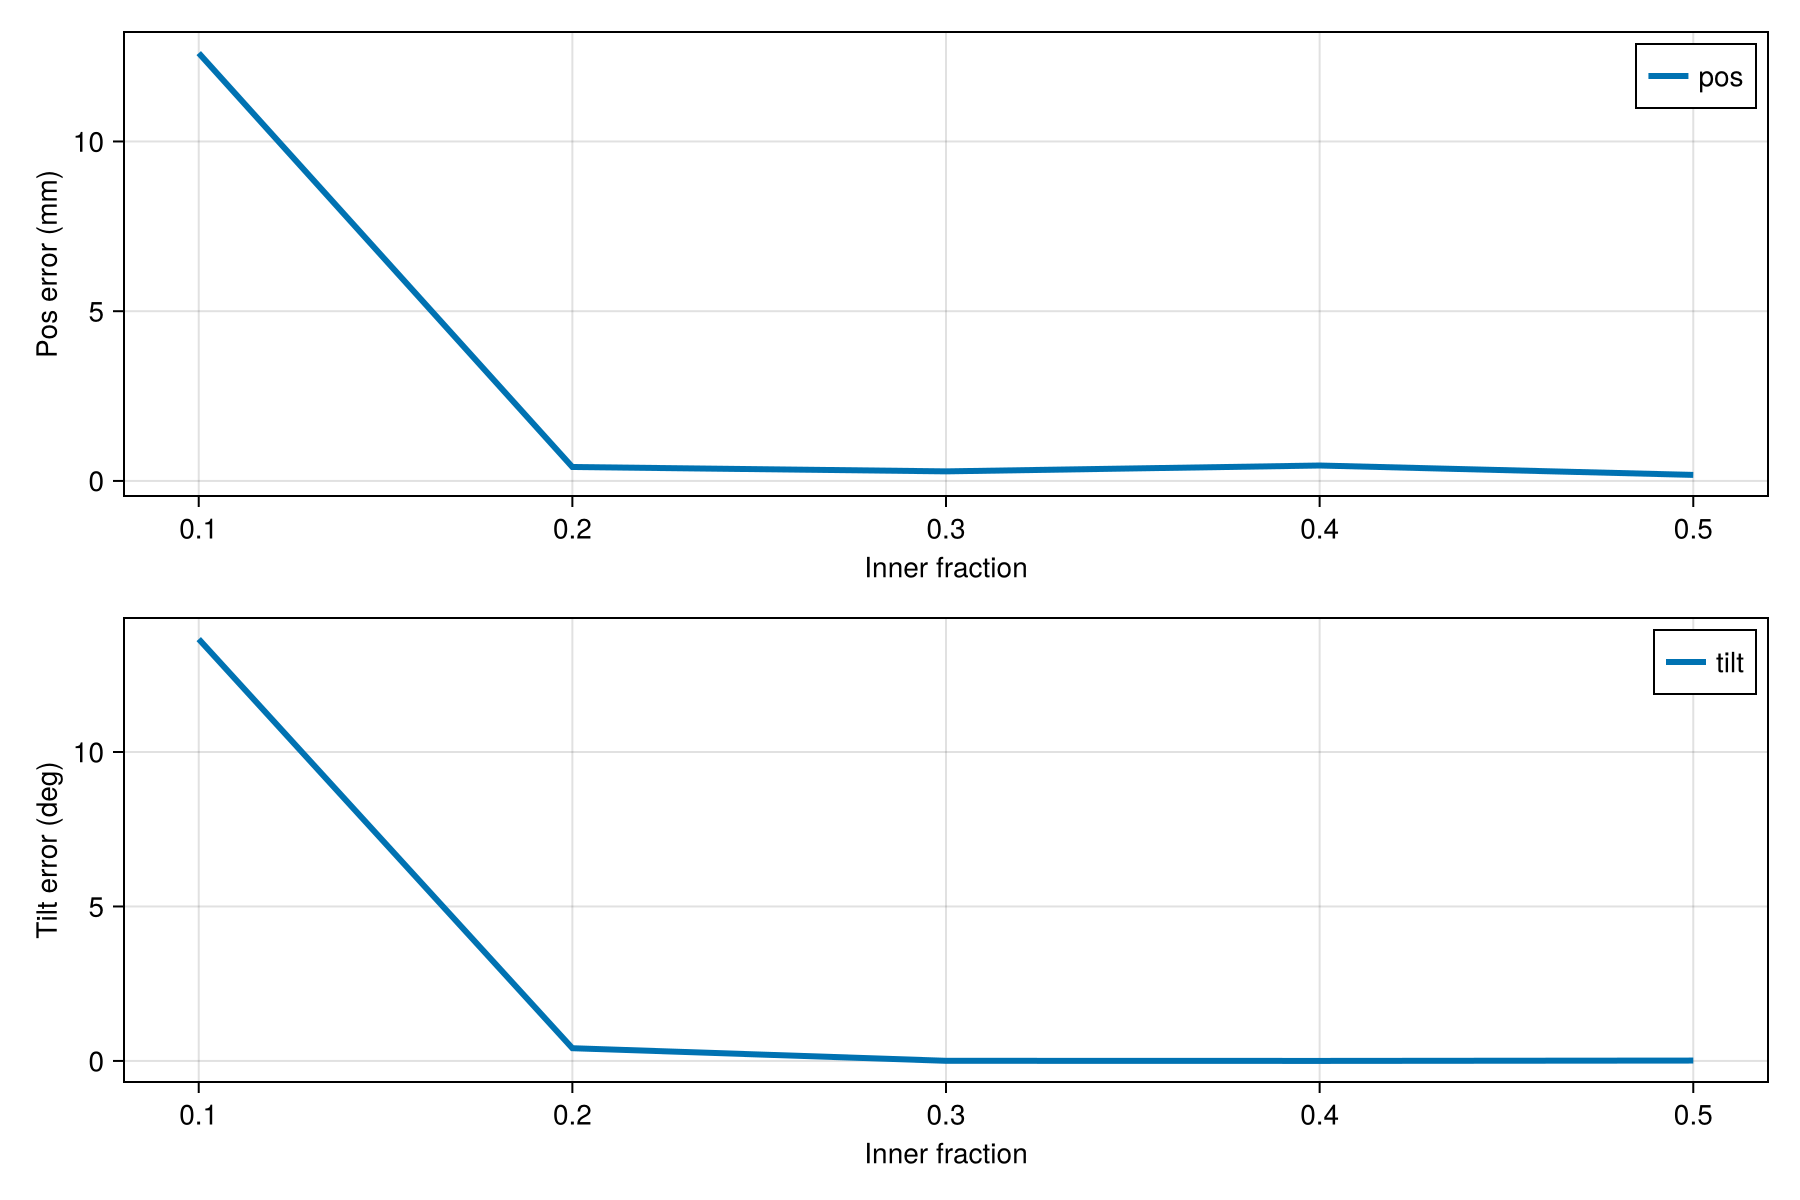

In [33]:
using CairoMakie

Ns = [24]
noise_fracs = [0.001]

inner_fracs = collect(range(0.5, 0.1, length=5))
outer_frac = 0.50

pos_vals  = Float64[]
tilt_vals = Float64[]

# ------------------------------------------------------------
# COMPUTE (flattened)
# ------------------------------------------------------------

for nf in noise_fracs

    for inner_frac in inner_fracs

        dx = Float64[]
        dy = Float64[]
        dz = Float64[]

        dtx = Float64[]
        dty = Float64[]

        for N in Ns
            try
                dr, phys, fld = run_scan(
                    shift_x = 0.03,
                    shift_y = 0.03,
                    shift_z = 0.03,

                    tilt_x_deg = 0.5,
                    tilt_y_deg = 0.5,

                    n_phi_inner = N,
                    n_z_inner   = N,

                    hall_r_inner_frac = inner_frac,
                    hall_r_outer_frac = outer_frac,

                    add_noise_frac = nf,
                )

                println("OK | inner=$inner_frac dr=$dr")

                push!(dx, abs(fld.x0 - phys.x0 - 0.03) * 1e3)
                push!(dy, abs(fld.y0 - phys.y0 - 0.03) * 1e3)
                push!(dz, abs(fld.z0 - phys.z0 - 0.03) * 1e3)

                push!(dtx, abs(fld.tilt_x - phys.tilt_x - 0.5))
                push!(dty, abs(fld.tilt_y - phys.tilt_y - 0.5))

            catch e
                println("FAIL inner=$inner_frac")
                println(e)
            end
        end

        if isempty(dx)
            println("SKIP inner=$inner_frac (no data)")
            continue
        end

        push!(pos_vals, mean((dx .+ dy .+ dz) ./ 3))
        push!(tilt_vals, mean((dtx .+ dty) ./ 2))
    end
end

# ------------------------------------------------------------
# PLOT (NOW SIMPLE AND CORRECT)
# ------------------------------------------------------------

fig = Figure(size = (900, 600))

ax1 = Axis(fig[1, 1], xlabel="Inner fraction", ylabel="Pos error (mm)")
ax2 = Axis(fig[2, 1], xlabel="Inner fraction", ylabel="Tilt error (deg)")

lines!(ax1, inner_fracs, pos_vals, linewidth=3, label="pos")
lines!(ax2, inner_fracs, tilt_vals, linewidth=3, label="tilt")

axislegend(ax1)
axislegend(ax2)

fig

FAIL inner=0.4 outer=0.6
FAIL inner=0.3 outer=0.6
FAIL inner=0.2 outer=0.6
FAIL inner=0.1 outer=0.6
FAIL inner=0.5 outer=0.5
FAIL inner=0.3 outer=0.5
FAIL inner=0.2 outer=0.5
FAIL inner=0.2 outer=0.4
FAIL inner=0.5 outer=0.3


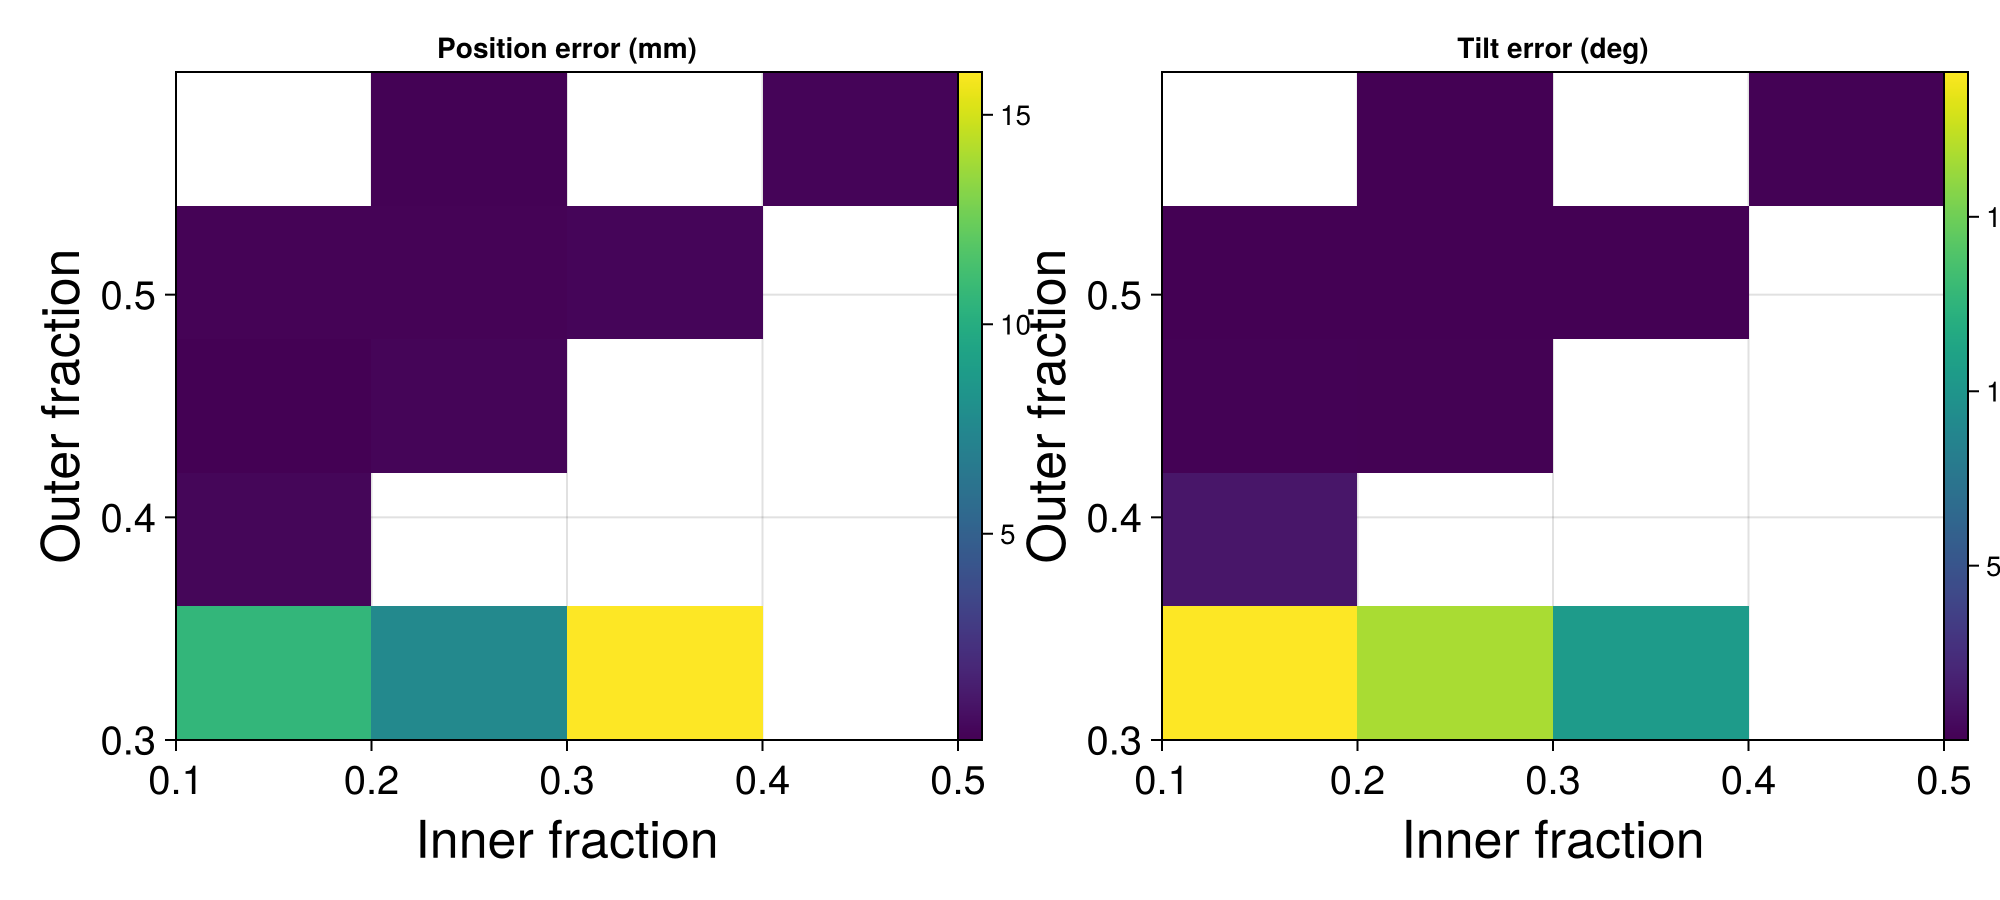

In [64]:
using CairoMakie

Ns = [24]
noise_fracs = [0.001]

inner_fracs = collect(range(0.5, 0.1, length=5))
outer_fracs = collect(range(0.6, 0.3, length=4))

# store as matrices: (outer, inner)
pos_map  = zeros(length(outer_fracs), length(inner_fracs))
tilt_map = zeros(length(outer_fracs), length(inner_fracs))

# ------------------------------------------------------------
# COMPUTE
# ------------------------------------------------------------

for (oi, ofr) in enumerate(outer_fracs)
    for (ii, ifr) in enumerate(inner_fracs)

        dx = Float64[]
        dy = Float64[]
        dz = Float64[]

        dtx = Float64[]
        dty = Float64[]

        for N in Ns
            try
                dr, phys, fld = run_scan(
                    shift_x = 0.03,
                    shift_y = 0.03,
                    shift_z = 0.03,

                    tilt_x_deg = 0.5,
                    tilt_y_deg = 0.5,

                    n_phi_inner = N,
                    n_z_inner   = N,

                    hall_r_inner_frac = ifr,
                    hall_r_outer_frac = ofr,

                    add_noise_frac = 0.001,
                )

                push!(dx, abs(fld.x0 - phys.x0 - 0.03) * 1e3)
                push!(dy, abs(fld.y0 - phys.y0 - 0.03) * 1e3)
                push!(dz, abs(fld.z0 - phys.z0 - 0.03) * 1e3)

                push!(dtx, abs(fld.tilt_x - phys.tilt_x - 0.5))
                push!(dty, abs(fld.tilt_y - phys.tilt_y - 0.5))

            catch e
                println("FAIL inner=$ifr outer=$ofr")
            end
        end

        if isempty(dx)
            pos_map[oi, ii]  = NaN
            tilt_map[oi, ii] = NaN
        else
            pos_map[oi, ii]  = mean((dx .+ dy .+ dz) ./ 3)
            tilt_map[oi, ii] = mean((dtx .+ dty) ./ 2)
        end
    end
end

# ------------------------------------------------------------
# PLOT (heatmaps show relationship structure)
# ------------------------------------------------------------

fig = Figure(size = (1000, 450))

ax1 = Axis(fig[1, 1],
    xlabel = "Inner fraction",
    ylabel = "Outer fraction",
    title  = "Position error (mm)"
)

ax2 = Axis(fig[1, 2],
    xlabel = "Inner fraction",
    ylabel = "Outer fraction",
    title  = "Tilt error (deg)"
)
ax1.xlabelsize = ax2.xlabelsize = 26
ax1.ylabelsize = ax2.ylabelsize = 26
ax1.xticklabelsize = ax2.xticklabelsize = 20
ax1.yticklabelsize = ax2.yticklabelsize = 20
hm1 = heatmap!(ax1, inner_fracs, outer_fracs, pos_map)
Colorbar(fig[1, 1, Right()], hm1)

hm2 = heatmap!(ax2, inner_fracs, outer_fracs, tilt_map)
Colorbar(fig[1, 2, Right()], hm2)

fig

In [ ]:
using CairoMakie, Statistics

Ns = [24]
noise_fracs = [0.001]

inner_fracs = collect(range(0.5, 0.1, length=7))
outer_fracs = collect(range(0.7, 0.4, length=7))

pos_map  = fill(NaN, length(outer_fracs), length(inner_fracs))
tilt_map = fill(NaN, length(outer_fracs), length(inner_fracs))

# ------------------------------------------------------------
# COMPUTE
# ------------------------------------------------------------

for (oi, ofr) in enumerate(outer_fracs)
    for (ii, ifr) in enumerate(inner_fracs)

        dx = Float64[]
        dy = Float64[]
        dz = Float64[]
        dtx = Float64[]
        dty = Float64[]

        for N in Ns
            try
                dr, phys, fld = run_scan(
                    shift_x = 0.03,
                    shift_y = 0.03,
                    shift_z = 0.03,

                    tilt_x_deg = 0.5,
                    tilt_y_deg = 0.5,

                    n_phi_inner = N,
                    n_z_inner   = N,

                    hall_r_inner_frac = ifr,
                    hall_r_outer_frac = ofr,

                    add_noise_frac = 0.001,
                )

                push!(dx, abs(fld.x0 - phys.x0 - 0.03) * 1e3)
                push!(dy, abs(fld.y0 - phys.y0 - 0.03) * 1e3)
                push!(dz, abs(fld.z0 - phys.z0 - 0.03) * 1e3)

                push!(dtx, abs(fld.tilt_x - phys.tilt_x - 0.5))
                push!(dty, abs(fld.tilt_y - phys.tilt_y - 0.5))

            catch e
                println("FAIL inner=$ifr outer=$ofr | ", e)
            end
        end

        if !isempty(dx)
            pos_map[oi, ii]  = mean((dx .+ dy .+ dz) ./ 3)
            tilt_map[oi, ii] = mean((dtx .+ dty) ./ 2)
        end
    end
end

# ------------------------------------------------------------
# PLOT
# ------------------------------------------------------------

fig = Figure(size = (1200, 520))

ax1 = Axis(fig[1, 1],
    xlabel = "Inner fraction",
    ylabel = "Outer fraction",
    title  = "Position error (mm)"
)

ax2 = Axis(fig[1, 2],
    xlabel = "Inner fraction",
    ylabel = "Outer fraction",
    title  = "Tilt error (deg)"
)

# FIX: valid Makie colormap (green → red)
cmap = reverse(:RdYlGn)

hm1 = heatmap!(ax1, inner_fracs, outer_fracs, pos_map; colormap = cmap)
hm2 = heatmap!(ax2, inner_fracs, outer_fracs, tilt_map; colormap = cmap)

cb1 = Colorbar(fig[1, 3], hm1, label = "Position error (mm)")
cb2 = Colorbar(fig[1, 4], hm2, label = "Tilt error (deg)")

# ensure full visibility (fix cutoff)
colgap!(fig.layout, 10)
colsize!(fig.layout, 3, Auto(0.10))
colsize!(fig.layout, 4, Auto(0.10))

cb1.width = 20
cb2.width = 20

fig

In [ ]:
using CairoMakie

cmap = cgrad(:RdYlGn, rev = true)

pos_rng  = (0.01, 10.0)
tilt_rng = (0.01, 5.0)

pos_ticks  = range(pos_rng[1], pos_rng[2], length=6) |> collect
tilt_ticks = range(tilt_rng[1], tilt_rng[2], length=6) |> collect

fig = Figure(size = (1200, 520))

ax1 = Axis(fig[1, 1],
    xlabel = "Inner Shell Radius Fraction",
    ylabel = "Outer Shell Radius Fraction",

)

ax2 = Axis(fig[1, 2],
    xlabel = "Inner Shell Radius Fraction",
    ylabel = "Outer Shell Radius Fraction",

)

hm1 = heatmap!(ax1, inner_fracs, outer_fracs, pos_map;
    colormap = cmap,
    colorrange = pos_rng
)

hm2 = heatmap!(ax2, inner_fracs, outer_fracs, tilt_map;
    colormap = cmap,
    colorrange = tilt_rng
)

# IMPORTANT: no formatter
cb1 = Colorbar(fig[1, 3], hm1;
    label = "mm",
    ticks = round.(Int,pos_ticks)
)

cb2 = Colorbar(fig[1, 4], hm2;
    label = "deg",
    ticks = round.(Int,tilt_ticks)
)
ax1.xlabelsize = ax2.xlabelsize = 26
ax1.ylabelsize = ax2.ylabelsize = 26
ax1.xticklabelsize = ax2.xticklabelsize = 20
ax1.yticklabelsize = ax2.yticklabelsize = 20
colgap!(fig.layout, 10)
colsize!(fig.layout, 3, Auto(0.08))
colsize!(fig.layout, 4, Auto(0.08))

fig

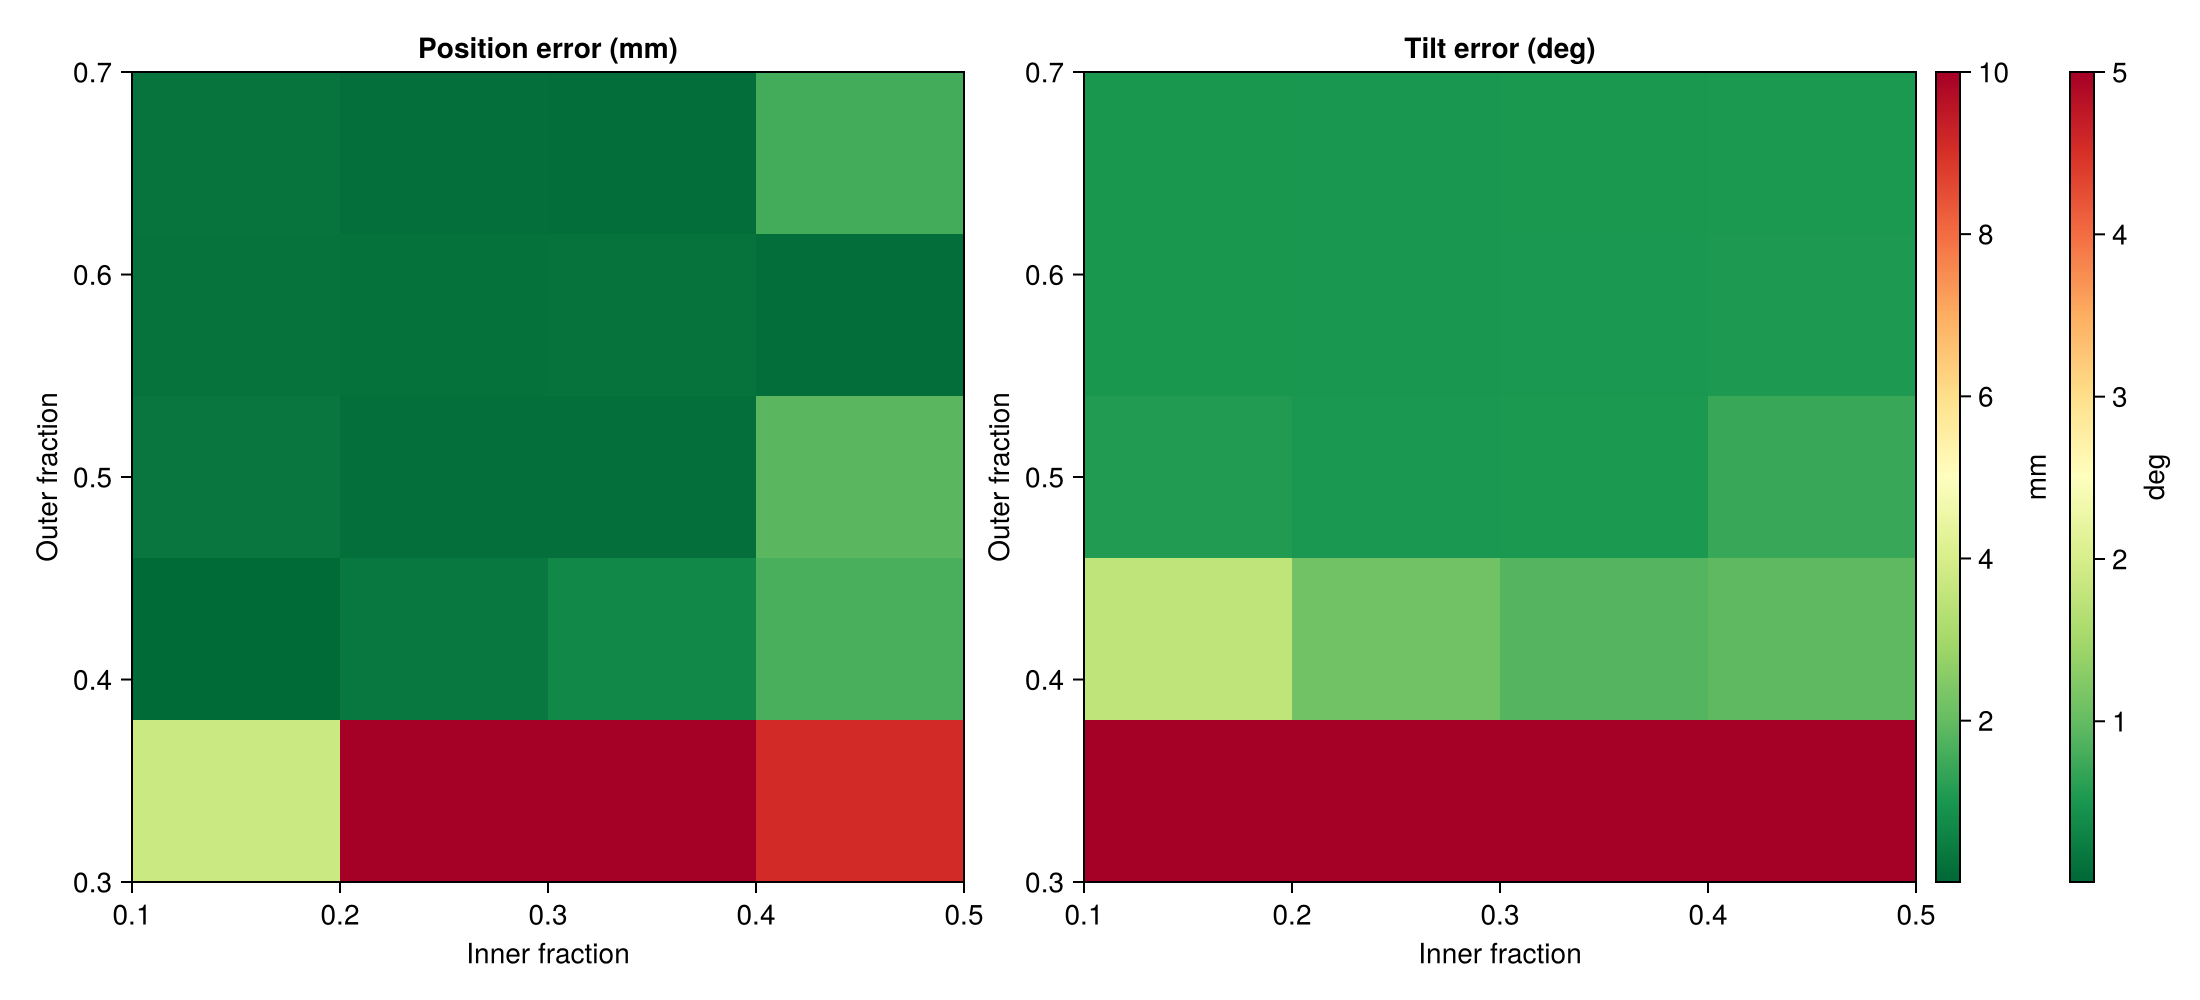

In [17]:
using CairoMakie

Ns = [24]
noise_fracs = [0.001]

inner_fracs = collect(range(0.5, 0.1, length=5))
outer_fracs = collect(range(0.7, 0.3, length=4))

pos_map  = fill(NaN, length(outer_fracs), length(inner_fracs))
tilt_map = fill(NaN, length(outer_fracs), length(inner_fracs))

# ------------------------------------------------------------
# PRECOMPUTE (CRITICAL SPEED FIX)
# run geometry + hall export ONCE
# ------------------------------------------------------------

base_phys_file  = "sparc_pf1u.dat"
base_field_file = "coil_out.dat"
base_hall_csv   = "A_Hall_Test.csv"

transform_coil(
    base_phys_file,
    base_field_file;
    shift_x = 0.03,
    shift_y = 0.03,
    shift_z = 0.03,
    tilt_x_deg = 0.5,
    tilt_y_deg = 0.5,
    tilt_z_deg = 0.0,
)

export_hall_csv_notebook(
    coil_file = base_field_file,
    out_csv   = base_hall_csv,
    current_A = 100.0
)

# ------------------------------------------------------------
# COMPUTE (ONLY SCANNING VARIES NOW)
# ------------------------------------------------------------

for (oi, ofr) in enumerate(outer_fracs)
    for (ii, ifr) in enumerate(inner_fracs)

        dx = Float64[]
        dy = Float64[]
        dz = Float64[]
        dtx = Float64[]
        dty = Float64[]

        for N in Ns
            try
                dr, phys, fld = run_scan(
                    # geometry already fixed → no transform_coil here
                    shift_x = 0.0,
                    shift_y = 0.0,
                    shift_z = 0.0,

                    tilt_x_deg = 0.5,
                    tilt_y_deg = 0.5,

                    n_phi_inner = N,
                    n_z_inner   = N,

                    hall_r_inner_frac = ifr,
                    hall_r_outer_frac = ofr,

                    add_noise_frac = 0.001,
                )

                push!(dx, abs(fld.x0 - phys.x0) * 1e3)
                push!(dy, abs(fld.y0 - phys.y0) * 1e3)
                push!(dz, abs(fld.z0 - phys.z0) * 1e3)

                push!(dtx, abs(fld.tilt_x - phys.tilt_x))
                push!(dty, abs(fld.tilt_y - phys.tilt_y))

            catch e
                println("FAIL inner=$ifr outer=$ofr | ", e)
            end
        end

        if !isempty(dx)
            pos_map[oi, ii]  = mean((dx .+ dy .+ dz) ./ 3)
            tilt_map[oi, ii] = mean((dtx .+ dty) ./ 2)
        end
    end
end

# ------------------------------------------------------------
# PLOT
# ------------------------------------------------------------

cmap = cgrad(:RdYlGn, rev=true)

fig = Figure(size = (1100, 500))

ax1 = Axis(fig[1, 1],
    xlabel = "Inner fraction",
    ylabel = "Outer fraction",
    title  = "Position error (mm)"
)

ax2 = Axis(fig[1, 2],
    xlabel = "Inner fraction",
    ylabel = "Outer fraction",
    title  = "Tilt error (deg)"
)

hm1 = heatmap!(ax1, inner_fracs, outer_fracs, pos_map;
    colormap = cmap,
    colorrange = (0.01, 10.0)
)

hm2 = heatmap!(ax2, inner_fracs, outer_fracs, tilt_map;
    colormap = cmap,
    colorrange = (0.01, 5.0)
)

Colorbar(fig[1, 3], hm1, label="mm")
Colorbar(fig[1, 4], hm2, label="deg")

colgap!(fig.layout, 10)
colsize!(fig.layout, 3, Auto(0.08))
colsize!(fig.layout, 4, Auto(0.08))

fig